# 커피 가격, 5거래일 뒤를 예측해 보기

2016~2025년 Parquet 12개를 묶고, **아무 변화도 없다고 보는 예측 → Ridge → CatBoost** 순서로 비교한다. 가격에서 만든 피처는 Close만 사용한다. OHLC를 억지로 보정하지 않으려는 선택이다.

예측 기준은 거래일 T의 **UTC 23:00**. 아래에서는 자료를 관측일보다 늦게 붙이고 학습 경계도 비운다. 다만 저장된 파일에는 과거 발표시각과 수정 전 값이 없다. 이번 결과는 **공개 지연을 가정한 과거 데이터 벤치마크**이며, 당시 실제로 받을 수 있었던 데이터 전체를 재현한 실험은 아니다.

In [1]:
import platform
import matplotlib.pyplot as plt

# 한글 폰트 설정
if platform.system() == "Windows":
    plt.rc("font", family="Malgun Gothic")
elif platform.system() == "Darwin":  # macOS
    plt.rc("font", family="AppleGothic")
else:
    # !apt-get -qq install -y fonts-nanum
    plt.rc("font", family="NanumGothic")

plt.rc("axes", unicode_minus=False)


In [2]:
from pathlib import Path
import warnings

import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import pandas_market_calendars as mcal
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.sm_exceptions import InterpolationWarning
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.multitest import multipletests
from catboost import CatBoostRegressor
from IPython.display import display
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd() if (Path.cwd() / "configs").is_dir() else Path.cwd().parent
DATA_DIR = ROOT / "data/processed/2016-01-01_2025-12-31"
SEED = 42
TARGET = "future_log_return_5d"

sns.set_theme(style="whitegrid", context="notebook", palette="colorblind", font=plt.rcParams["font.family"][0])
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False, "grid.alpha": 0.25})
pd.set_option("display.max_rows", 25)

region_labels = {
    "br_alta_mogiana": "브라질 알타 모지아나",
    "br_cerrado": "브라질 세라도",
    "br_sul_minas": "브라질 술 지 미나스",
    "co_antioquia": "콜롬비아 안티오키아",
    "co_caldas": "콜롬비아 칼다스",
    "co_huila": "콜롬비아 우일라",
}
source_labels = {
    "coffee": "아라비카 선물 (KC=F)",
    "brl": "브라질 환율 (BRL/USD)",
    "dff": "미국 연방기금금리",
    "dtwexbgs": "광의 달러지수",
    "dcoilwtico": "WTI 현물가격",
    "cot": "투자자 포지션 (COT)",
    **{f"weather_{region}": f"{label} 기상" for region, label in region_labels.items()},
}
feature_labels = {
    "log_return_1d": "1거래일 로그수익률",
    "log_return_5d": "5거래일 로그수익률",
    "log_return_20d": "20거래일 로그수익률",
    "volatility_20d": "20거래일 변동성",
    "brl_close": "브라질 환율 (BRL/USD)",
    "dff": "미국 연방기금금리",
    "dtwexbgs": "광의 달러지수",
    "dcoilwtico": "WTI 현물가격",
    "cot_net_ratio": "매니지드 머니 순매수 비율",
    TARGET: "5거래일 뒤 로그수익률",
}
for region, label in region_labels.items():
    feature_labels[f"{region}_rain_30d"] = f"{label} · 30일 누적 강수량"
    feature_labels[f"{region}_temp_30d"] = f"{label} · 30일 평균 기온"
model_labels = {"Naive Persistence": "가격 유지 (Naive)", "Ridge Regression": "Ridge 회귀", "CatBoost": "CatBoost"}
metric_labels = {
    "MAE": "평균절대오차 (MAE)",
    "RMSE": "제곱평균제곱근오차 (RMSE)",
    "Directional Accuracy (%)": "방향성 정확도 (%)",
}

sources = {}
for path in sorted(DATA_DIR.glob("*.parquet")):
    frame = pd.read_parquet(path).sort_values("date").reset_index(drop=True)
    frame["date"] = pd.to_datetime(frame["date"]).astype("datetime64[ns]")
    assert frame["date"].notna().all() and frame["date"].is_unique, path.name
    sources[path.stem] = frame
assert len(sources) == 12

display(
    pd.DataFrame(
        [
            {
                "source": source_labels[name],
                "rows": len(frame),
                "start": frame.date.min().date(),
                "end": frame.date.max().date(),
                "missing_cells": int(frame.isna().sum().sum()),
            }
            for name, frame in sources.items()
        ]
    )
    .set_index("source")
    .rename_axis("데이터")
    .rename(
        columns={
            "rows": "row 수",
            "start": "시작일",
            "end": "종료일",
            "missing_cells": "결측치 수",
        }
    )
)

,row 수,시작일,종료일,결측치 수
데이터,,,,
브라질 환율 (BRL/USD),2609,2016-01-01,2025-12-31,28
아라비카 선물 (KC=F),2519,2016-01-04,2025-12-31,16
투자자 포지션 (COT),522,2016-01-05,2025-12-30,0
WTI 현물가격,2609,2016-01-01,2025-12-31,108
미국 연방기금금리,3653,2016-01-01,2025-12-31,0
광의 달러지수,2609,2016-01-01,2025-12-31,117
브라질 알타 모지아나 기상,3713,2015-12-02,2026-01-30,0
브라질 세라도 기상,3713,2015-12-02,2026-01-30,0
브라질 술 지 미나스 기상,3713,2015-12-02,2026-01-30,0


## 1. 날짜부터 맞추기

결측 행을 먼저 지우면 `shift(-5)`가 원래보다 먼 날짜를 가리킬 수 있다. 그래서 거래일 칸부터 만들고, 빠진 가격은 NaN으로 남긴다. 가격을 앞으로 채워 가짜 수익률을 만들지는 않는다.

미국 공통 휴장일은 NYSE 달력을 바탕으로 잡고, ICE가 개장한 [2018-12-05](https://www.ice.com/publicdocs/clear_us/notices/18-054_IFUS_ICUS_President_HW_Bush.pdf)와 [2025-01-09](https://www.ice.com/publicdocs/clear_us/notices/25-002_ICUS_President_Jimmy_Carter.pdf)는 따로 더했다. Yahoo에 값이 있는 [2023년 추수감사절](https://www.ice.com/publicdocs/futures_us/exchange_notices/ICE_Futures_US_2023Thanksgiving_Holiday_20230921.pdf)과 [2025년 독립기념일](https://www.ice.com/publicdocs/futures_us/exchange_notices/ICE_Futures_US_2025_IndDayHoliday_20250508.pdf)은 Coffee 휴장일이라 제외한다. 아래 표는 이 달력과 원본의 차이다. 원본 Parquet는 바꾸지 않는다.

In [3]:
coffee = sources["coffee"].set_index("date")
sessions = mcal.get_calendar("NYSE").valid_days("2016-01-01", "2025-12-31").tz_localize(None)
sessions = sessions.union(pd.to_datetime(["2018-12-05", "2025-01-09"])).sort_values()
sessions = sessions.as_unit("ns")
excluded = coffee.index.difference(sessions)
missing = sessions.difference(coffee.index)
display(
    pd.concat(
        [
            pd.DataFrame({"date": excluded, "status": "휴장일 행 제외"}),
            pd.DataFrame({"date": missing, "status": "누락 거래일은 결측으로 유지"}),
        ]
    )
    .sort_values("date")
    .reset_index(drop=True)
    .rename(columns={"date": "날짜", "status": "처리 내용"})
)

prices = coffee[["close"]].reindex(sessions).rename_axis("date").reset_index()
log_close = np.log(prices["close"].where(prices["close"] > 0))
PRICE_FEATURES = ["log_return_1d", "log_return_5d", "log_return_20d", "volatility_20d"]
for lag in (1, 5, 20):
    prices[f"log_return_{lag}d"] = log_close.diff(lag)
prices["volatility_20d"] = prices["log_return_1d"].rolling(20, min_periods=20).std()
prices[TARGET] = log_close.shift(-5) - log_close
prices["target_date"] = prices["date"].shift(-5)
prices["future_close"] = prices["close"].shift(-5)
prices["prediction_at"] = prices["date"] + pd.Timedelta(hours=23)  # 시각은 모두 UTC
assert prices["target_date"].iloc[:-5].reset_index(drop=True).equals(prices["date"].iloc[5:].reset_index(drop=True))

,날짜,처리 내용
0,2016-01-18,휴장일 행 제외
1,2016-02-15,휴장일 행 제외
2,2016-10-10,누락 거래일은 결측으로 유지
3,2016-11-11,누락 거래일은 결측으로 유지
4,2018-12-05,누락 거래일은 결측으로 유지
5,2023-11-23,휴장일 행 제외
6,2025-05-26,휴장일 행 제외
7,2025-06-19,휴장일 행 제외
8,2025-07-04,휴장일 행 제외


## 2. 관측일과 쓸 수 있는 날짜 구분하기

날짜가 같다고 바로 붙이기에는 공개 주기가 다르다. [광의 달러지수는 전주 자료를 주 단위로 공개](https://www.federalreserve.gov/releases/h10/about.htm)하고, [COT는 보통 화요일 포지션을 금요일에 공개](https://www.cftc.gov/MarketReports/CommitmentsofTraders/ReleaseSchedule/index.htm)한다. [NASA 기상 자료도 며칠 늦게 들어오며](https://power.larc.nasa.gov/docs/faqs/data/), [나중에 자료가 교체될 수 있다](https://power.larc.nasa.gov/docs/methodology/data/sources/).

아래 일수는 정확한 발표시각 대신 여유를 둔 **달력일 기준 가정**이다. BRL 1일, DFF 4일, 달러지수 14일, WTI 7일, 기상 4일, COT 7일. FRED는 과거 방향으로만 채우고, `merge_asof(direction="backward")`로 T 이전에 사용 가능한 마지막 값을 가져온다.

COT의 큰 발표 지연은 [2019년 재개 일정](https://www.cftc.gov/PressRoom/PressReleases/7864-19)과 [2023·2025년 특별 공지](https://www.cftc.gov/MarketReports/CommitmentsofTraders/HistoricalSpecialAnnouncements/index.htm)를 반영했다. 해당 보고서는 기본 지연일과 공지된 발표일 다음 날 중 더 늦은 날부터 사용한다.

### 기상 원자료는 멀쩡한데 왜 NaN이 생겼을까?

2016년 1월부터 잘라서 30일 평균을 계산하면 첫 29일에는 관측값이 모자란다. 우일라의 기온을 예로 들어 버퍼 전후를 다시 계산해 봤다. 아래는 **기상 관측일 기준 비교**다. 모델에는 이후 4일의 공개 지연을 적용한다.

2015년 12월 관측값을 함께 넣으면 1월 집계에도 30일이 채워진다. 미래 값을 당겨 채우거나 계절을 무시한 중앙값을 넣을 필요가 없었다.

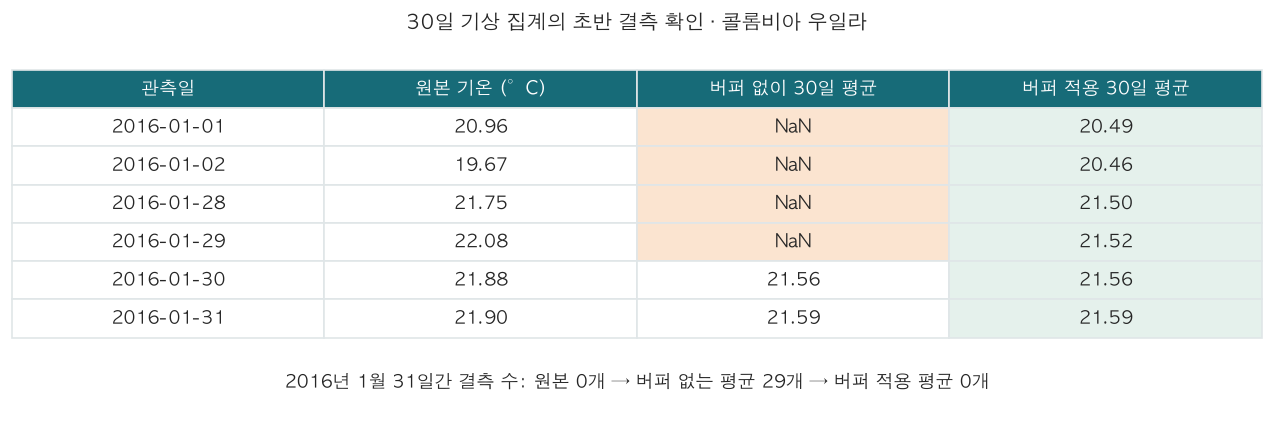

In [ ]:
daily_temp = sources["weather_co_huila"].set_index("date")["T2M"].asfreq("D")
january_temp = daily_temp.loc["2016-01-01":"2016-01-31"]
before_buffer = january_temp.rolling("30D", min_periods=30).mean()
after_buffer = daily_temp.rolling("30D", min_periods=30).mean().reindex(january_temp.index)
assert january_temp.notna().all()
assert before_buffer.isna().sum() == 29 and after_buffer.notna().all()

warmup_comparison = pd.DataFrame(
    {
        "원본 기온 (°C)": january_temp,
        "버퍼 없이 30일 평균": before_buffer,
        "버퍼 적용 30일 평균": after_buffer,
    }
)
# 시작일과 30개 관측값이 처음 쌓이는 경계를 함께 본다.
sample = warmup_comparison.loc[
    pd.to_datetime(["2016-01-01", "2016-01-02", "2016-01-28", "2016-01-29", "2016-01-30", "2016-01-31"])
].map(lambda value: "NaN" if pd.isna(value) else f"{value:.2f}")
sample.insert(0, "관측일", sample.index.strftime("%Y-%m-%d"))
fig, ax = plt.subplots(figsize=(10.5, 3.4), layout="constrained")
ax.axis("off")
ax.set_title("30일 기상 집계의 초반 결측 확인 · 콜롬비아 우일라", pad=14)
table = ax.table(cellText=sample.values, colLabels=sample.columns, cellLoc="center", bbox=[0, 0.2, 1, 0.75])
table.auto_set_font_size(False)
table.set_fontsize(11)
for (row, column), cell in table.get_celld().items():
    cell.set_edgecolor("#E0E6E8")
    if row == 0:
        cell.set_facecolor("#176B78")
        cell.get_text().set_color("white")
    elif cell.get_text().get_text() == "NaN":
        cell.set_facecolor("#FBE4D0")
    elif column == 3:
        cell.set_facecolor("#E5F1EC")
ax.text(
    0.5,
    0.06,
    f"2016년 1월 31일간 결측 수: 원본 {january_temp.isna().sum()}개 → 버퍼 없는 평균 {before_buffer.isna().sum()}개 → 버퍼 적용 평균 {after_buffer.isna().sum()}개",
    ha="center",
    transform=ax.transAxes,
    fontsize=11,
)
plt.show()


In [5]:
LAG_DAYS = {"brl": 1, "dff": 4, "dtwexbgs": 14, "dcoilwtico": 7, "weather": 4, "cot": 7}
joined = prices.copy()
FEATURES = PRICE_FEATURES.copy()
join_checks = []


def join_source(left, right, name, columns, lag_days):
    right = right.copy()
    if "available_at" not in right:
        right["available_at"] = right["date"] + pd.Timedelta(days=lag_days)
    observed, available = f"{name}_observed_at", f"{name}_available_at"
    right = right.rename(columns={"date": observed, "available_at": available})
    result = pd.merge_asof(
        left.sort_values("prediction_at"),
        right[[observed, available, *columns]].sort_values(available),
        left_on="prediction_at",
        right_on=available,
        direction="backward",
    )
    matched = result[available].notna()
    assert len(result) == len(left)
    assert (result.loc[matched, available] <= result.loc[matched, "prediction_at"]).all()
    assert (result.loc[matched, observed] <= result.loc[matched, available]).all()
    join_checks.append({"source": name, "matched_rows": int(matched.sum()), "total_rows": len(result)})
    return result


brl = sources["brl"][["date", "close"]].rename(columns={"close": "brl_close"}).dropna()
joined = join_source(joined, brl, "brl", ["brl_close"], LAG_DAYS["brl"])
FEATURES.append("brl_close")
for name in ("dff", "dtwexbgs", "dcoilwtico"):
    fred = sources[name][["date", "value"]].copy()
    fred[name] = fred.pop("value").ffill()  # 휴일의 빈칸도 이전 값만 사용한다
    joined = join_source(joined, fred, name, [name], LAG_DAYS[name])
    FEATURES.append(name)

for name, frame in sources.items():
    if not name.startswith("weather_"):
        continue
    region = name.removeprefix("weather_")
    daily = frame.set_index("date").asfreq("D")
    rain, temp = f"{region}_rain_30d", f"{region}_temp_30d"
    # 앞뒤 30일 버퍼를 포함해 계산한다. 현재 관측일까지의 30달력일만 쓴다.
    weather = pd.DataFrame(
        {
            rain: daily["PRECTOTCORR"].rolling("30D", min_periods=30).sum(),
            temp: daily["T2M"].rolling("30D", min_periods=30).mean(),
        }
    ).reset_index()
    joined = join_source(joined, weather, name, [rain, temp], LAG_DAYS["weather"])
    FEATURES.extend([rain, temp])

In [6]:
cot = sources["cot"].copy()
cot["cot_net_ratio"] = (cot["managed_money_long"] - cot["managed_money_short"]) / cot["open_interest"].replace(
    0, np.nan
)
cot["available_at"] = cot["date"] + pd.Timedelta(days=LAG_DAYS["cot"])

# 보고 기준일 순서의 발표 일정. 발표가 멈춘 동안 새 포지션을 미리 쓰지 않는다.
cot_release_delays = [
    (
        "2018-12-24",
        "2019-03-05",
        "2019-02-01 2019-02-05 2019-02-08 2019-02-12 2019-02-15 2019-02-19 "
        "2019-02-22 2019-02-26 2019-03-01 2019-03-05 2019-03-08",
    ),
    ("2023-01-31", "2023-03-14", "2023-02-24 2023-03-03 2023-03-08 2023-03-10 2023-03-14 2023-03-16 2023-03-21"),
    (
        "2025-09-30",
        "2025-12-23",
        "2025-11-19 2025-11-21 2025-11-25 2025-12-02 2025-12-05 2025-12-09 "
        "2025-12-10 2025-12-12 2025-12-15 2025-12-17 2025-12-19 2025-12-23 2025-12-29",
    ),
]
for start, end, release_days in cot_release_delays:
    mask = cot["date"].between(start, end)
    release_after = pd.to_datetime(release_days.split()) + pd.Timedelta(days=1)
    assert mask.sum() == len(release_after)
    cot.loc[mask, "available_at"] = np.maximum(cot.loc[mask, "available_at"].to_numpy(), release_after.to_numpy())

joined = join_source(joined, cot, "cot", ["cot_net_ratio"], LAG_DAYS["cot"])
FEATURES.append("cot_net_ratio")
assert len(FEATURES) == len(set(FEATURES)) == 21
assert TARGET not in FEATURES and "future_close" not in FEATURES
# 가격 피처의 초기 구간과 정답이 없는 행만 제외한다. 기상은 버퍼로 집계해 대치하지 않는다.
data = joined.dropna(subset=["close", "target_date", TARGET, *PRICE_FEATURES]).copy()
assert np.isfinite(data[FEATURES].to_numpy()).all(), "피처 결측이 생기면 원인을 먼저 확인한다."
display(
    pd.DataFrame(join_checks)
    .set_index("source")
    .rename(index=source_labels)
    .rename_axis("데이터")
    .rename(columns={"matched_rows": "연결된 행 수", "total_rows": "전체 행 수"})
)

,연결된 행 수,전체 행 수
데이터,,
브라질 환율 (BRL/USD),2516,2516
미국 연방기금금리,2515,2516
광의 달러지수,2507,2516
WTI 현물가격,2512,2516
브라질 알타 모지아나 기상,2516,2516
브라질 세라도 기상,2516,2516
브라질 술 지 미나스 기상,2516,2516
콜롬비아 안티오키아 기상,2516,2516
콜롬비아 칼다스 기상,2516,2516


## 3. EDA와 시간 순서 분할

2016~2021년으로 학습하고 2022~2023년으로 설정을 고른다. 그다음 2016~2023년으로 다시 학습해 기존 2024~2025년 테스트 구간과 비교한다. 타깃 날짜가 다음 구간으로 넘어가는 마지막 5거래일은 학습·검증에서 뺀다.

기상 원자료에는 결측이 없었다. 앞선 초반 결측은 30일 집계에 필요한 과거 관측값이 부족해서 생겼다. 중앙값으로 메우면 그날의 계절과 상관없는 값이 들어가므로, **기상 파일만 앞뒤 30일(2015-12-02~2026-01-30) 늘리고 대치 코드를 없앴다.** 뒤쪽 버퍼는 저장만 하고 해당 예측 시점보다 늦은 관측값은 쓰지 않는다. 가격의 20거래일 피처에는 별도의 초기 구간이 필요해 실제 학습 시작일은 2월이다.

EDA는 2016~2023년 개발 구간에서만 본다. 먼저 분포와 계절성을 보고, 현재 종가와의 관계가 5거래일 뒤 수익률에서도 나타나는지 나눠 확인한다. 이 분석으로 피처를 자동 선택하거나 테스트에 맞춰 모델 설정을 바꾸지는 않는다.

In [7]:
VAL_START = pd.Timestamp("2022-01-01")
TEST_START = pd.Timestamp("2024-01-01")
TEST_END = pd.Timestamp("2025-12-31")
train = data.loc[(data["date"] < VAL_START) & (data["target_date"] < VAL_START)]
val = data.loc[data["date"].between(VAL_START, TEST_START, inclusive="left") & (data["target_date"] < TEST_START)]
dev = data.loc[(data["date"] < TEST_START) & (data["target_date"] < TEST_START)]
test = data.loc[data["date"].between(TEST_START, TEST_END) & (data["target_date"] <= TEST_END)]
assert train["target_date"].max() < val["date"].min()
assert dev["target_date"].max() < test["date"].min()
assert set(dev.index).isdisjoint(test.index)

display(
    pd.DataFrame(
        [
            {
                "split": name,
                "rows": len(frame),
                "first_origin": frame.date.min().date(),
                "last_origin": frame.date.max().date(),
                "last_target": frame.target_date.max().date(),
            }
            for name, frame in [("학습", train), ("검증", val), ("재학습 (2016~2023)", dev), ("테스트", test)]
        ]
    )
    .set_index("split")
    .rename_axis("구간")
    .rename(
        columns={
            "rows": "행 수",
            "first_origin": "첫 예측 기준일",
            "last_origin": "마지막 예측 기준일",
            "last_target": "마지막 정답 날짜",
        }
    )
)
eda_columns = [*PRICE_FEATURES, "cot_net_ratio", TARGET]
display(
    dev[eda_columns]
    .describe(percentiles=[0.05, 0.5, 0.95])
    .T.round(4)
    .rename(
        index=feature_labels,
        columns={
            "count": "관측 수",
            "mean": "평균",
            "std": "표준편차",
            "min": "최솟값",
            "5%": "5% 분위",
            "50%": "중앙값",
            "95%": "95% 분위",
            "max": "최댓값",
        },
    )
    .rename_axis("피처")
)
weather_features = [name for name in FEATURES if name.endswith(("_rain_30d", "_temp_30d"))]
assert joined[weather_features].notna().all().all()
print(f"기상 피처 결측: {int(joined[weather_features].isna().sum().sum())}개 | 대치한 값: 0개")


,행 수,첫 예측 기준일,마지막 예측 기준일,마지막 정답 날짜
구간,,,,
학습,1422,2016-02-02,2021-12-23,2021-12-31
검증,496,2022-01-03,2023-12-21,2023-12-29
재학습 (2016~2023),1923,2016-02-02,2023-12-21,2023-12-29
테스트,498,2024-01-02,2025-12-23,2025-12-31


,관측 수,평균,표준편차,최솟값,5% 분위,중앙값,95% 분위,최댓값
피처,,,,,,,,
1거래일 로그수익률,1923.0,0.0003,0.0205,-0.0902,-0.0327,-0.0004,0.0352,0.0956
5거래일 로그수익률,1923.0,0.0017,0.0453,-0.1844,-0.0661,-0.0007,0.0782,0.2915
20거래일 로그수익률,1923.0,0.0064,0.0852,-0.2691,-0.1284,0.0000,0.1514,0.2787
20거래일 변동성,1923.0,0.0197,0.0057,0.0078,0.0122,0.0186,0.0293,0.0467
매니지드 머니 순매수 비율,1923.0,-0.0115,0.1558,-0.3471,-0.2543,0.0184,0.1941,0.2653
5거래일 뒤 로그수익률,1923.0,0.0013,0.0454,-0.1844,-0.0663,-0.0014,0.0782,0.2915


기상 피처 결측: 0개 | 대치한 값: 0개


### 분포와 계절성

단위가 다른 변수를 한 축에 올리면 작은 값은 잘 보이지 않는다. 가격·환율·거시지표는 축을 나누고, 기상은 같은 단위끼리 묶었다. 박스 밖 점은 지우지 않는다. 수익률의 큰 움직임이나 WTI 음수 관측도 먼저 원자료와 맥락을 확인할 대상이다.

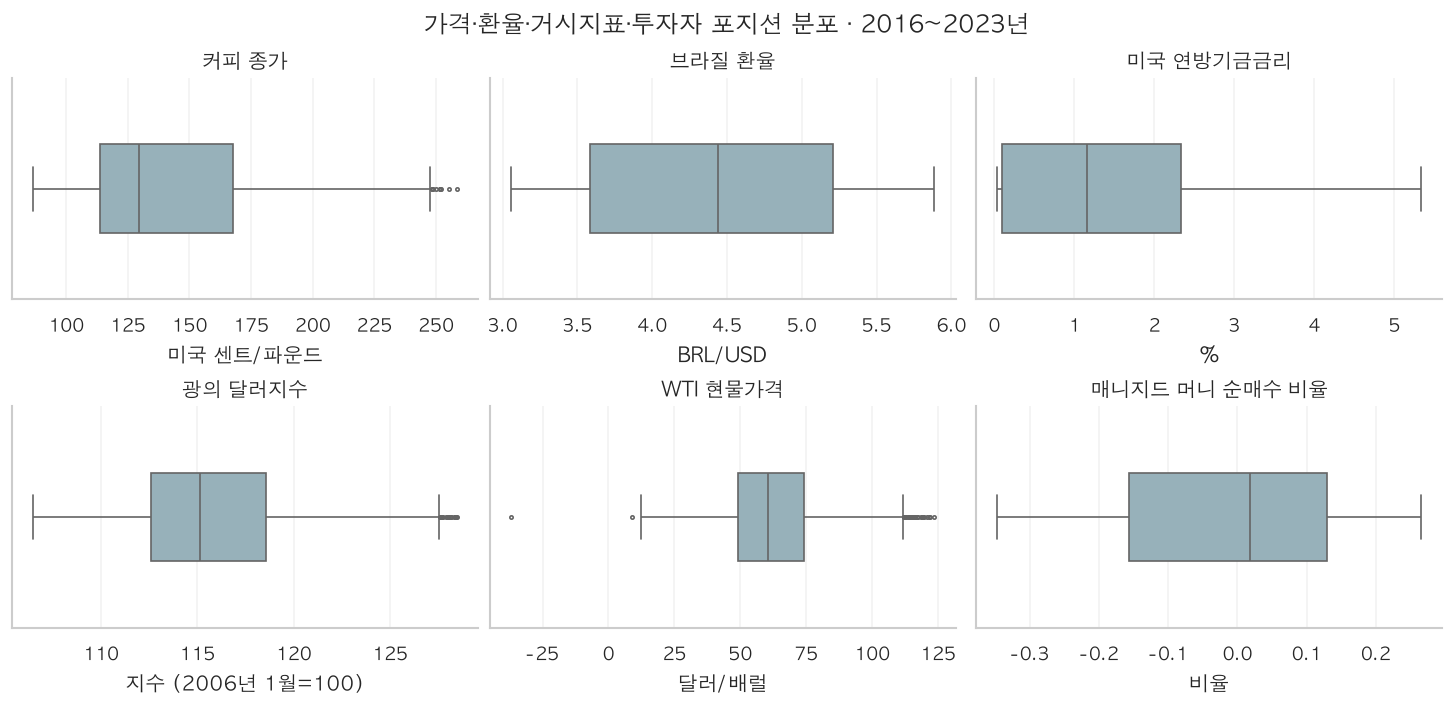

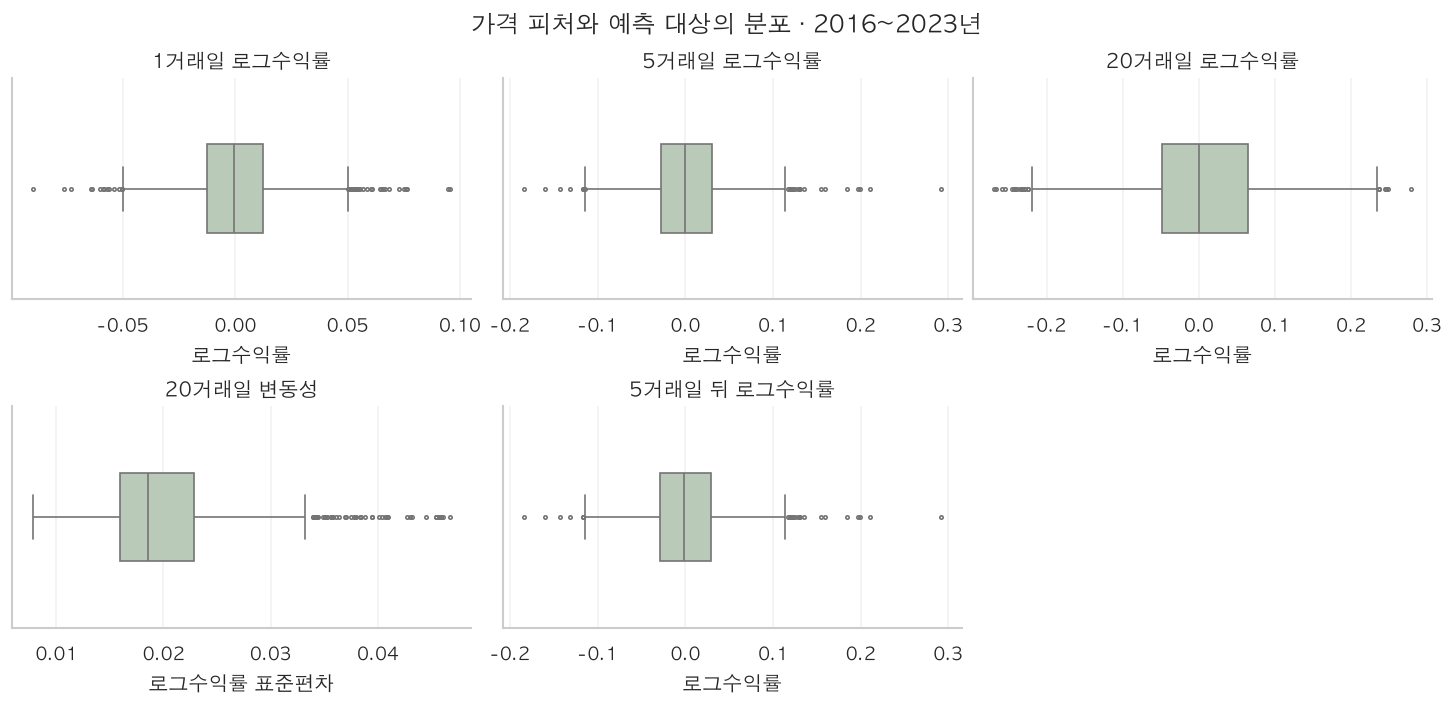

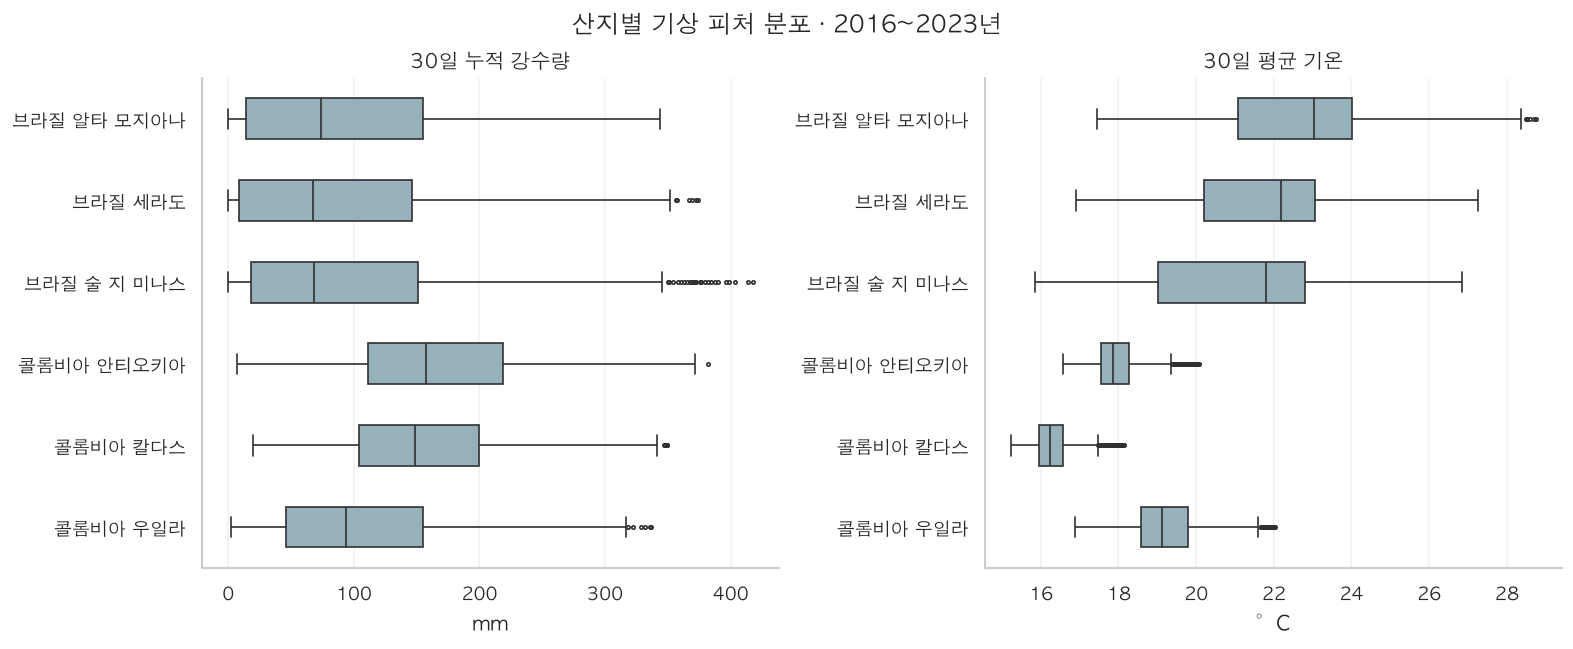

In [ ]:
short_labels = {
    **feature_labels,
    "close": "커피 종가",
    "brl_close": "브라질 환율",
    "dff": "미국 연방기금금리",
    "dtwexbgs": "광의 달러지수",
    "dcoilwtico": "WTI 현물가격",
    "cot_net_ratio": "매니지드 머니 순매수 비율",
}
for region, label in region_labels.items():
    short_labels[f"{region}_rain_30d"] = label + " 강수량"
    short_labels[f"{region}_temp_30d"] = label + " 기온"
units = {
    "close": "미국 센트/파운드",
    "brl_close": "BRL/USD",
    "dff": "%",
    "dtwexbgs": "지수 (2006년 1월=100)",
    "dcoilwtico": "달러/배럴",
    "cot_net_ratio": "비율",
    **{name: "로그수익률" for name in [*PRICE_FEATURES[:3], TARGET]},
    "volatility_20d": "로그수익률 표준편차",
    **{name: "mm" if name.endswith("_rain_30d") else "°C" for name in weather_features},
}
level_features = ["close", "brl_close", "dff", "dtwexbgs", "dcoilwtico", "cot_net_ratio"]
fig, axes = plt.subplots(2, 3, figsize=(12, 5.8), layout="constrained")
for ax, name in zip(axes.flat, level_features):
    sns.boxplot(x=dev[name], ax=ax, color="#91B4C0", width=0.4, fliersize=2)
    ax.set(title=short_labels[name], xlabel=units[name], ylabel="")
fig.suptitle("가격·환율·거시지표·투자자 포지션 분포 · 2016~2023년")
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(12, 5.8), layout="constrained")
for ax, name in zip(axes.flat, [*PRICE_FEATURES, TARGET]):
    sns.boxplot(x=dev[name], ax=ax, color="#B6CDB5", width=0.4, fliersize=2)
    ax.set(title=short_labels[name], xlabel=units[name], ylabel="")
axes.flat[-1].set_visible(False)
fig.suptitle("가격 피처와 예측 대상의 분포 · 2016~2023년")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.3), layout="constrained")
for ax, suffix, title, unit in zip(
    axes, ["rain_30d", "temp_30d"], ["30일 누적 강수량", "30일 평균 기온"], ["mm", "°C"]
):
    columns = [f"{region}_{suffix}" for region in region_labels]
    table = dev[columns].rename(columns={f"{region}_{suffix}": label for region, label in region_labels.items()})
    sns.boxplot(data=table, orient="h", ax=ax, color="#91B4C0", fliersize=2, width=0.5)
    ax.set(title=title, xlabel=unit, ylabel="")
fig.suptitle("산지별 기상 피처 분포 · 2016~2023년")
plt.show()


### 수익률의 꼬리는 정규분포보다 두꺼울까?

1·5·20거래일 수익률과 예측 대상인 미래 5거래일 수익률의 **왜도·첨도·Jarque–Bera(JB)**를 비교한다. 정규분포의 기준은 왜도 0, 첨도 3, 초과첨도 0이다. JB는 왜도와 첨도를 함께 확인하므로, 작은 p값만 보고 팻 테일이라고 결론 내리지 않고 초과첨도와 Q–Q plot도 같이 본다.

[SciPy의 JB 설명](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.jarque_bera.html)은 2,000개보다 큰 표본에서의 근사를 안내한다. 여기서는 개발 표본 1,923개를 쓰고, 5·20일 수익률은 이웃한 구간이 겹친다. 아래 p값은 독립·대표본 가정하의 탐색적 근사로 읽는다.

,표본 수,왜도,첨도,초과첨도,JB 통계량,JB p값 (근사),정규성 · 5% 기준
수익률,,,,,,,
1거래일 로그수익률,"1,923",0.210,4.156,1.156,121.211,4.78e-27,기각 (근사)
5거래일 로그수익률,"1,923",0.389,4.500,1.500,228.742,2.13e-50,기각 (근사)
20거래일 로그수익률,"1,923",0.039,3.137,0.137,1.980,3.72e-01,기각 못함
5거래일 뒤 로그수익률,"1,923",0.401,4.479,1.479,226.750,5.78e-50,기각 (근사)


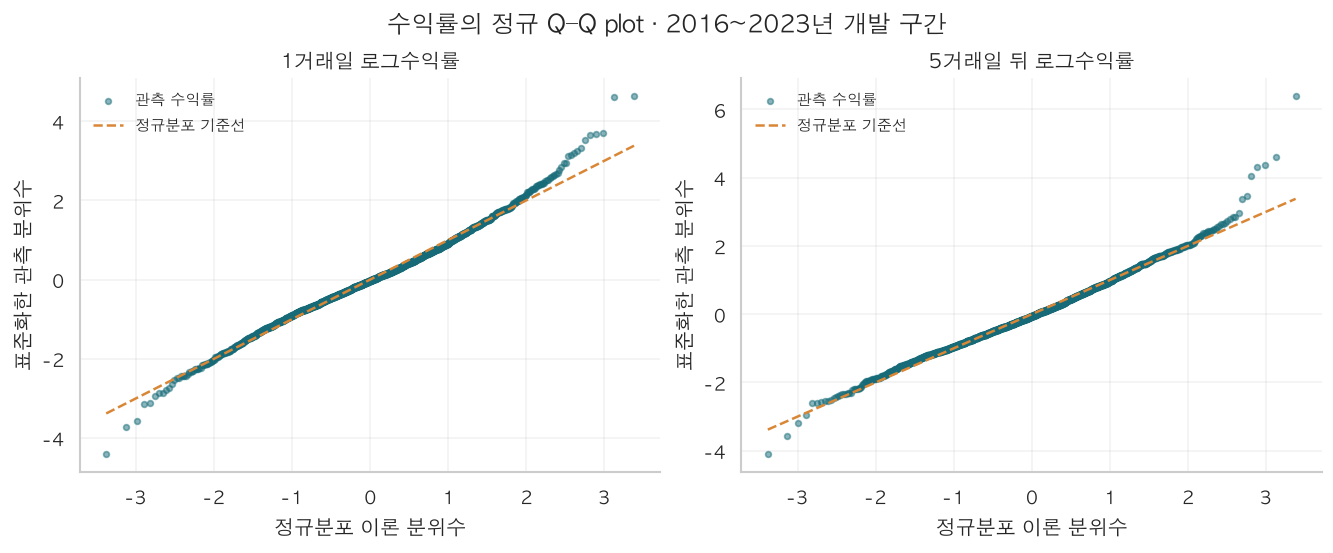

In [ ]:
return_columns = ["log_return_1d", "log_return_5d", "log_return_20d", TARGET]
normality_rows = []
for name in return_columns:
    values = dev[name].to_numpy()
    jb = stats.jarque_bera(values)
    excess = stats.kurtosis(values, fisher=True, bias=True)
    normality_rows.append(
        {
            "수익률": feature_labels[name],
            "표본 수": len(values),
            "왜도": stats.skew(values, bias=True),
            "첨도": excess + 3,
            "초과첨도": excess,
            "JB 통계량": jb.statistic,
            "JB p값 (근사)": jb.pvalue,
            "정규성 · 5% 기준": "기각 (근사)" if jb.pvalue < 0.05 else "기각 못함",
        }
    )
normality = pd.DataFrame(normality_rows).set_index("수익률")
display(
    normality.style.format(
        {
            "표본 수": "{:,.0f}",
            "왜도": "{:.3f}",
            "첨도": "{:.3f}",
            "초과첨도": "{:.3f}",
            "JB 통계량": "{:.3f}",
            "JB p값 (근사)": "{:.2e}",
        }
    )
)

# 같은 평균·분산의 정규분포와 비교한다. 양 끝이 기준선에서 얼마나 벌어지는지 본다.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), layout="constrained")
for ax, name in zip(axes, ["log_return_1d", TARGET]):
    values = dev[name]
    standardized = (values - values.mean()) / values.std(ddof=0)
    theoretical, observed = stats.probplot(standardized, dist="norm", fit=False)
    ax.scatter(theoretical, observed, s=12, alpha=0.5, color="#176B78", label="관측 수익률")
    ax.plot(theoretical, theoretical, color="#D98736", linestyle="--", label="정규분포 기준선")
    ax.set(title=feature_labels[name], xlabel="정규분포 이론 분위수", ylabel="표준화한 관측 분위수")
    ax.legend(frameon=False, fontsize=9)
fig.suptitle("수익률의 정규 Q–Q plot · 2016~2023년 개발 구간")
plt.show()


1일·5일 수익률과 미래 5일 수익률의 초과첨도는 각각 1.156·1.500·1.479였다. 정규분포보다 두꺼운 꼬리를 가진 표본 형태이고 JB 근사 p값도 작았다. 반면 20일 수익률은 초과첨도 0.137, p값 0.372로 정규성을 기각하지 못했다. 수익률이라고 모두 같은 분포로 묶기는 어려웠다.

### 가격 수준과 5거래일 수익률의 정상성

정규성은 분포의 모양이고, 정상성은 시간이 지나도 평균·공분산 같은 성질이 일정한가의 문제다. **[ADF](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.adfuller.html)의 귀무가설은 단위근이 있다는 것**, **[KPSS](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.kpss.html)의 귀무가설은 정상성**이다. 두 검정은 p값을 읽는 방향이 반대다.

누락된 거래일을 지운 뒤 앞뒤를 이어 붙이지 않으려고, 개발 기간 중 종가·과거 5일 수익률·미래 5일 수익률이 모두 있는 가장 긴 연속 거래일 구간을 사용한다. 상수항을 포함하고, ADF 지연 수는 AIC, KPSS 지연 수는 자동 선택으로 고정한다. 과거 수익률은 `ln(Pt / Pt-5)`, 예측 타깃은 `ln(Pt+5 / Pt)`다.

In [ ]:
stationarity_columns = ["close", "log_return_5d", TARGET]
calendar_dev = prices.loc[(prices["date"] < TEST_START) & (prices["target_date"] < TEST_START)]
complete = calendar_dev[stationarity_columns].notna().all(axis=1)
blocks = (~complete).cumsum()
longest_block = blocks[complete].value_counts().idxmax()
stationarity_sample = calendar_dev.loc[complete & blocks.eq(longest_block)]
assert np.all(np.diff(stationarity_sample.index.to_numpy()) == 1)
print(
    f"정상성 검정 구간: {stationarity_sample.date.min().date()} ~ {stationarity_sample.date.max().date()} "
    f"| 연속 거래일 {len(stationarity_sample):,}개"
)

stationarity_rows = []
for name in stationarity_columns:
    values = stationarity_sample[name]
    adf = adfuller(values, regression="c", autolag="AIC", result_object=True)
    with warnings.catch_warnings():
        # KPSS 표 범위 밖의 p값은 경고 대신 아래 표에 부등호로 표시한다.
        warnings.simplefilter("ignore", InterpolationWarning)
        kp = kpss(values, regression="c", nlags="auto", result_object=True)
    kp_p = (
        "<0.01"
        if kp.statistic > kp.critical_values["1%"]
        else ">0.10"
        if kp.statistic < kp.critical_values["10%"]
        else f"{kp.pvalue:.3f}"
    )
    stationarity_rows.append(
        {
            "시계열": short_labels[name],
            "ADF 통계량": adf.statistic,
            "ADF p값": adf.pvalue,
            "ADF 지연 수": adf.lags,
            "KPSS 통계량": kp.statistic,
            "KPSS p값": kp_p,
            "KPSS 지연 수": kp.lags,
        }
    )
stationarity = pd.DataFrame(stationarity_rows).set_index("시계열")
display(
    stationarity.style.format(
        {
            "ADF 통계량": "{:.3f}",
            "ADF p값": "{:.2e}",
            "KPSS 통계량": "{:.3f}",
        }
    )
)


정상성 검정 구간: 2018-12-13 ~ 2023-12-21 | 연속 거래일 1,265개


,ADF 통계량,ADF p값,ADF 지연 수,KPSS 통계량,KPSS p값,KPSS 지연 수
시계열,,,,,,
커피 종가,-1.456,5.55e-01,0,3.909,<0.01,21
5거래일 로그수익률,-6.832,1.88e-09,22,0.081,>0.10,16
5거래일 뒤 로그수익률,-6.905,1.25e-09,22,0.086,>0.10,16


연속 구간은 2018-12-13~2023-12-21의 1,265거래일이었다. 종가는 ADF p=0.555로 단위근을 기각하지 못했고, KPSS는 p<0.01로 수준 정상성을 기각했다. 과거 5일 수익률은 ADF p≈1.88×10⁻⁹, 미래 5일 수익률은 p≈1.25×10⁻⁹로 단위근을 기각했고 KPSS에서는 둘 다 p>0.10이었다.

이 구간과 검정 설정에서는 **가격 수준보다 5일 로그수익률을 정상 시계열로 다룰 근거가 있다.** 모든 시기의 분산까지 일정하다는 보장은 아니다. 앞에서 본 두꺼운 꼬리와도 모순되지 않는다. 정규분포가 아니어도 정상 시계열일 수 있다.

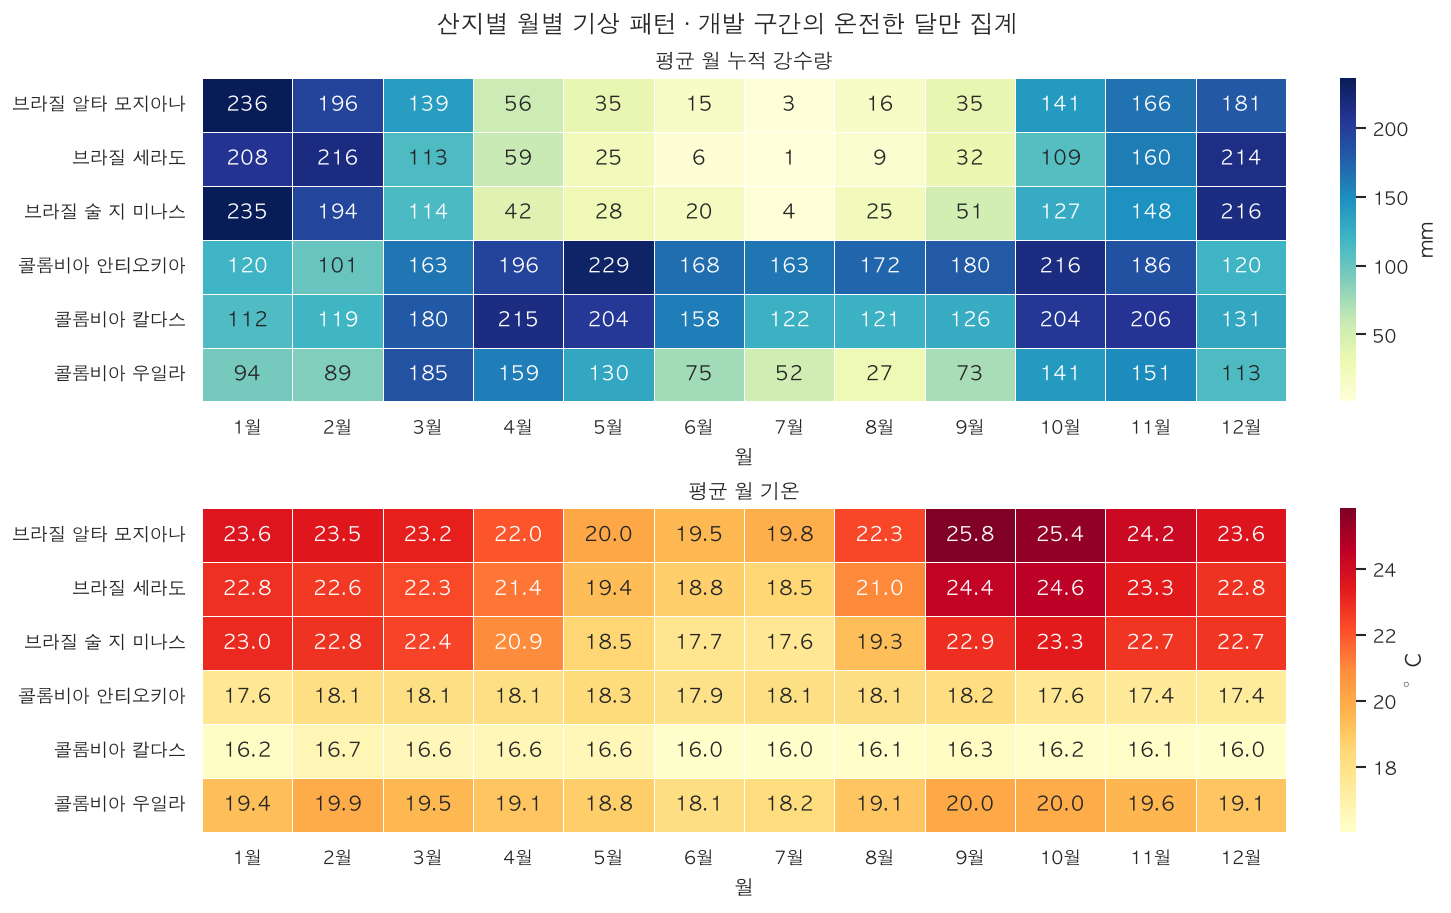

In [ ]:
# 기상은 거래일로 붙이기 전의 일별 원자료로 본다. 덜 모인 달은 월 비교에서 뺀다.
monthly_climate = []
for region in region_labels:
    raw = sources[f"weather_{region}"]
    raw = raw.loc[(raw["date"] >= "2016-01-01") & (raw["date"] + pd.Timedelta(days=LAG_DAYS["weather"]) < TEST_START)]
    monthly = (
        raw.set_index("date")
        .resample("MS")
        .agg(rain=("PRECTOTCORR", "sum"), temp=("T2M", "mean"), days=("T2M", "count"))
    )
    monthly = monthly.loc[monthly["days"] == monthly.index.days_in_month].copy()
    monthly["month"] = monthly.index.month
    monthly["region"] = region_labels[region]
    monthly_climate.append(monthly)
climate = pd.concat(monthly_climate).groupby(["region", "month"])[["rain", "temp"]].mean()
fig, axes = plt.subplots(2, 1, figsize=(12, 7.5), layout="constrained")
for ax, name, title, unit, color in zip(
    axes, ["rain", "temp"], ["평균 월 누적 강수량", "평균 월 기온"], ["mm", "°C"], ["YlGnBu", "YlOrRd"]
):
    table = climate[name].unstack("month").reindex(region_labels.values())
    table.columns = [f"{month}월" for month in table.columns]
    sns.heatmap(
        table,
        ax=ax,
        annot=True,
        fmt=".0f" if name == "rain" else ".1f",
        cmap=color,
        cbar_kws={"label": unit},
        linewidths=0.3,
    )
    ax.set(title=title, xlabel="월", ylabel="")
    ax.tick_params(axis="y", rotation=0)
fig.suptitle("산지별 월별 기상 패턴 · 개발 구간의 온전한 달만 집계")
plt.show()


### 변수 사이의 관계

Pearson은 선형 관계, Spearman은 값의 순서가 함께 움직이는 정도를 본다. 종가와 어떤 변수가 같이 상승했다고 해서 다음 주 수익률까지 설명되는 것은 아니다. 그래서 **종가와의 관계 / 실제 예측 대상과의 관계**를 함께 비교한다. 기상 피처끼리 비슷하게 움직이는지도 본다.

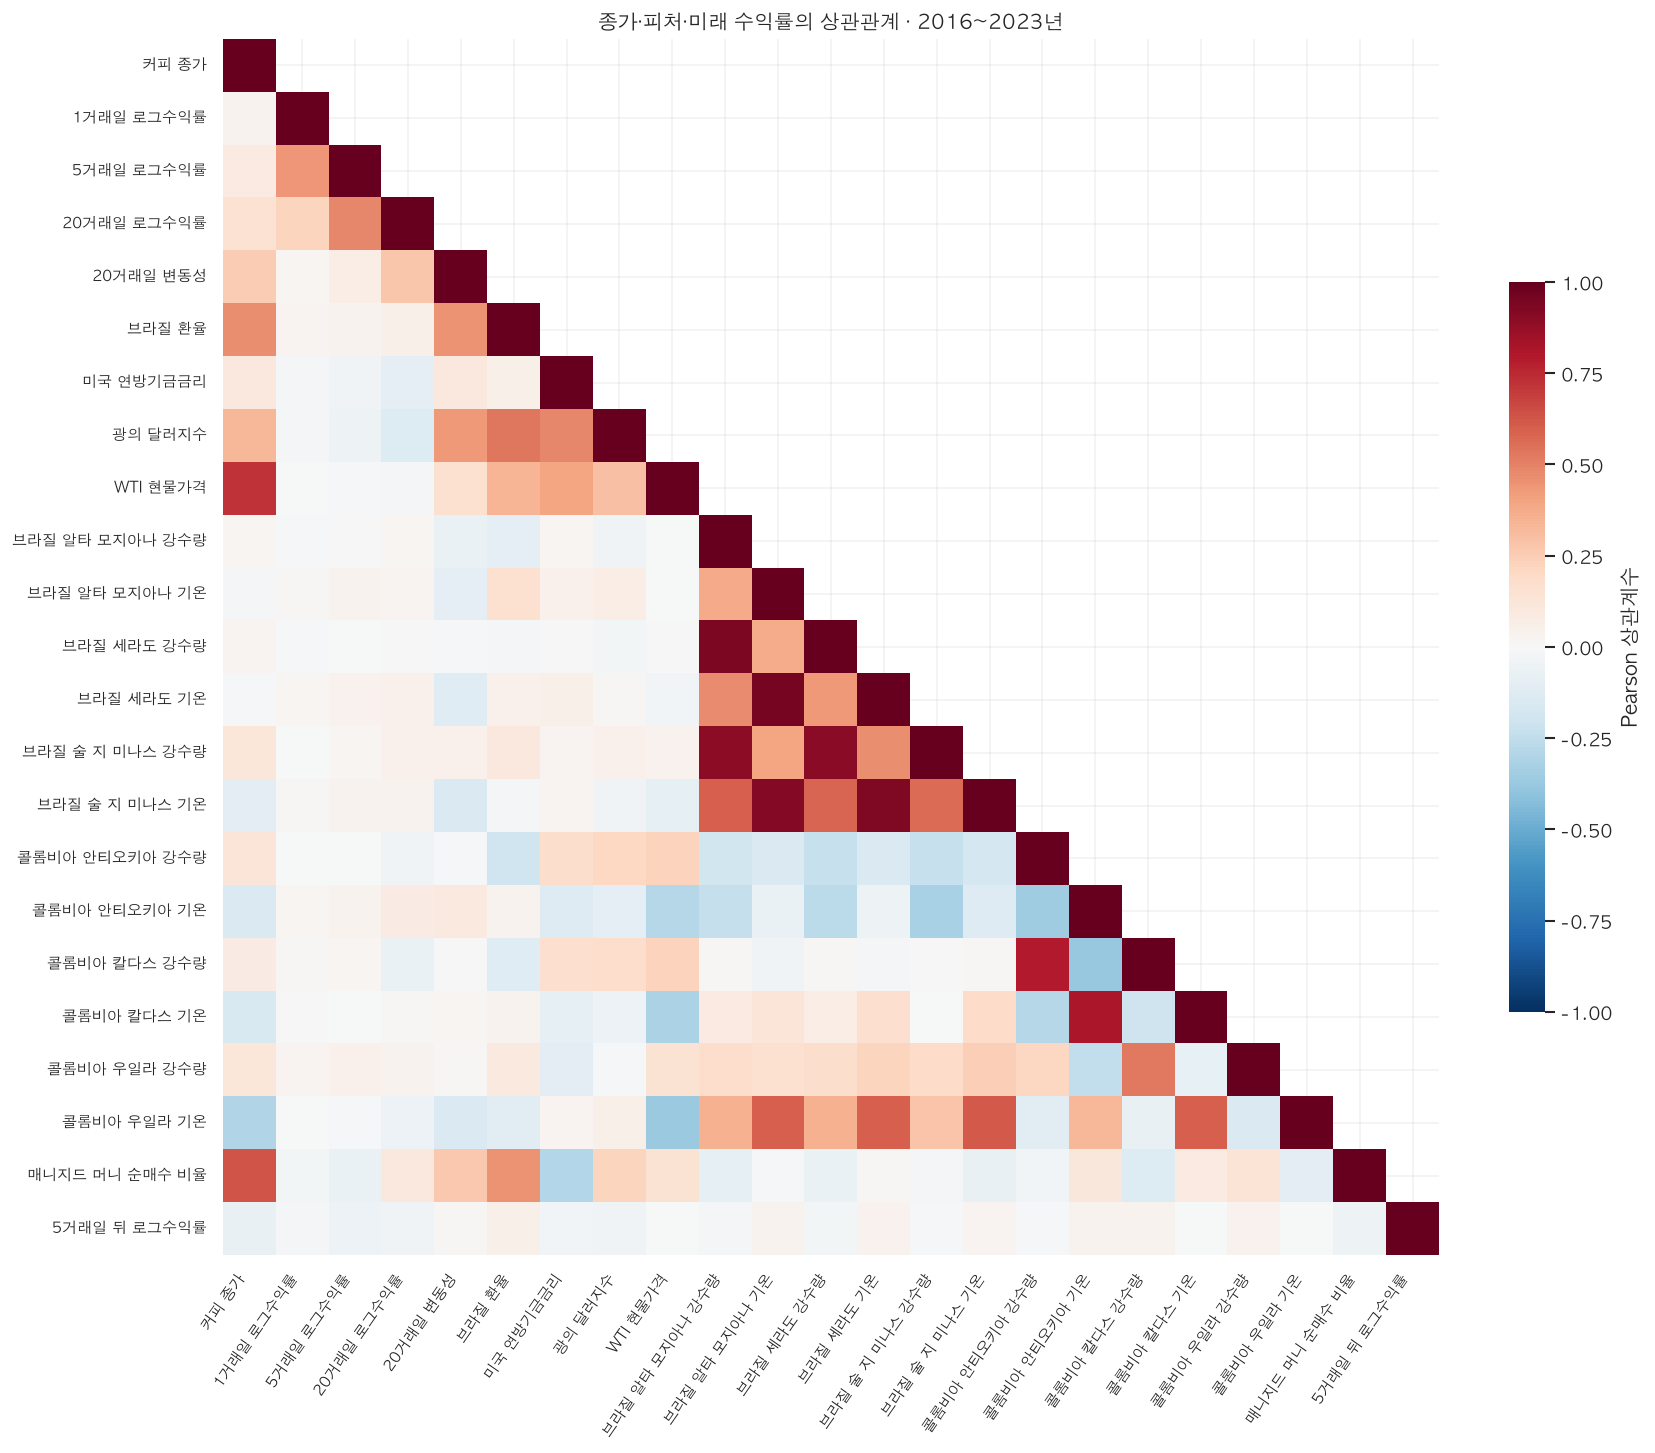

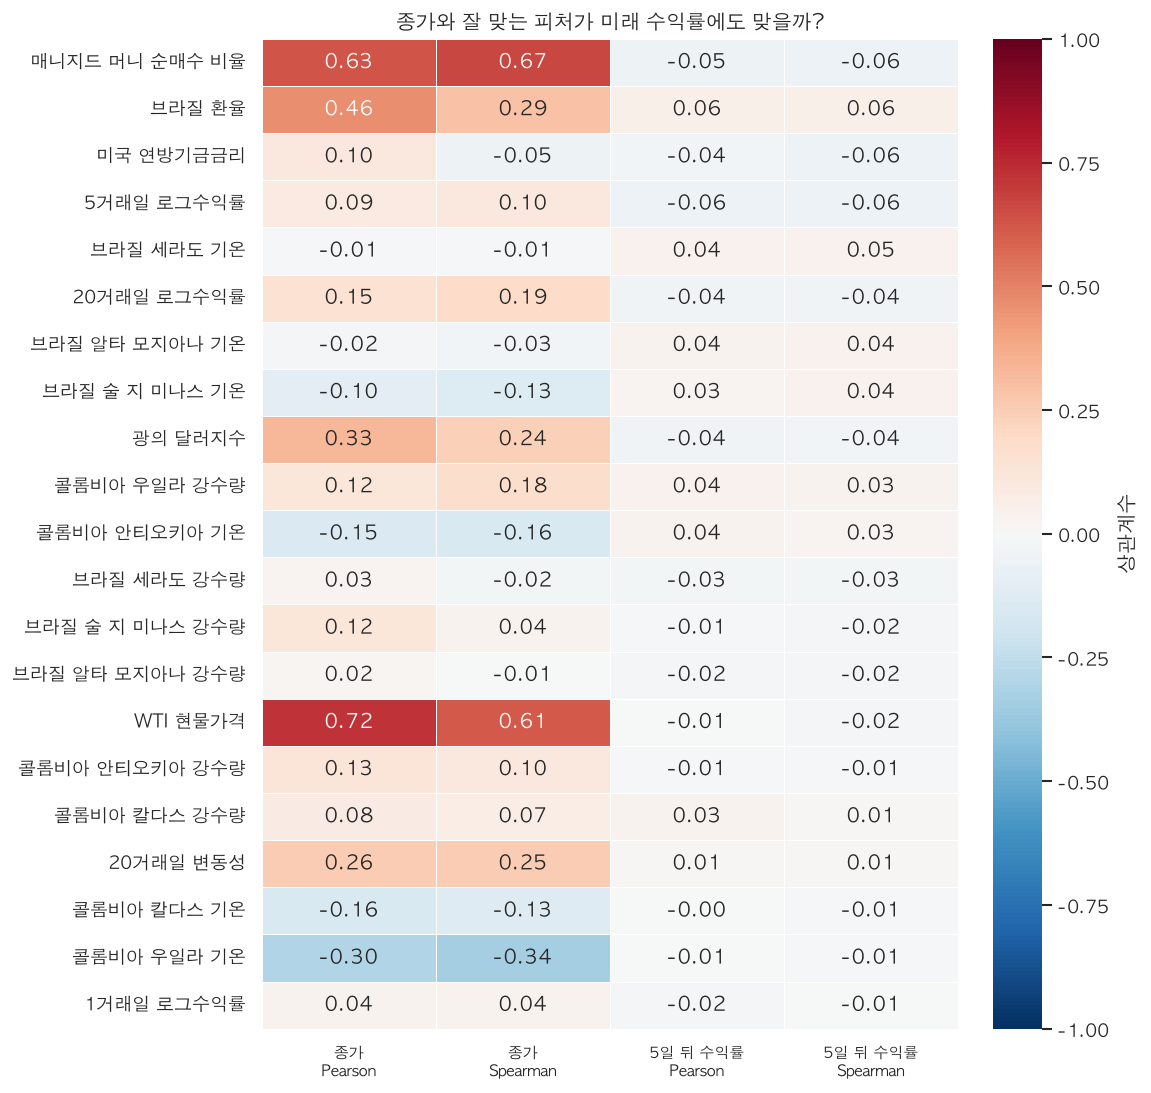

In [ ]:
corr_columns = ["close", *FEATURES, TARGET]
pearson = dev[corr_columns].corr(method="pearson")
spearman = dev[corr_columns].corr(method="spearman")
fig, ax = plt.subplots(figsize=(14, 12), layout="constrained")
sns.heatmap(
    pearson.rename(index=short_labels, columns=short_labels),
    mask=np.triu(np.ones_like(pearson, dtype=bool), k=1),
    vmin=-1,
    vmax=1,
    center=0,
    cmap="RdBu_r",
    square=True,
    ax=ax,
    cbar_kws={"label": "Pearson 상관계수", "shrink": 0.6},
)
ax.set(title="종가·피처·미래 수익률의 상관관계 · 2016~2023년", xlabel="", ylabel="")
ax.tick_params(axis="x", labelrotation=55, labelsize=9)
ax.tick_params(axis="y", labelrotation=0, labelsize=9)
plt.setp(ax.get_xticklabels(), ha="right")
plt.show()

relationships = pd.DataFrame(
    {
        "종가 · Pearson": pearson.loc[FEATURES, "close"],
        "종가 · Spearman": spearman.loc[FEATURES, "close"],
        "5일 뒤 수익률 · Pearson": pearson.loc[FEATURES, TARGET],
        "5일 뒤 수익률 · Spearman": spearman.loc[FEATURES, TARGET],
    }
)
order = relationships["5일 뒤 수익률 · Spearman"].abs().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(9.5, 9), layout="constrained")
sns.heatmap(
    relationships.loc[order].rename(index=short_labels, columns=lambda name: name.replace(" · ", "\n")),
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    center=0,
    cmap="RdBu_r",
    linewidths=0.4,
    ax=ax,
    cbar_kws={"label": "상관계수"},
)
ax.set(title="종가와 잘 맞는 피처가 미래 수익률에도 맞을까?", xlabel="", ylabel="")
ax.tick_params(axis="x", labelrotation=0, labelsize=9)
ax.tick_params(axis="y", labelrotation=0)
plt.show()


### 기상 피처의 다중공선성 사전 점검

6개 산지의 30일 평균 기온·누적 강수량, 총 12개만 따로 본다. **Pearson |r|≥0.8**인 조합을 추리고 Spearman도 함께 표시한다. 여러 피처가 합쳐져 겹치는 경우도 보려고 [VIF](https://www.statsmodels.org/stable/generated/statsmodels.stats.outliers_influence.variance_inflation_factor.html)를 계산했다. VIF는 이 기상 12개를 함께 넣었을 때의 값이며, 5 이상을 추가로 살펴볼 기준으로 잡았다.

상관이 높으면 선형 계수나 개별 피처 중요도를 해석할 때 주의가 필요하다. 이번에는 진단 결과를 남기고, 실제 피처 선택은 학습·검증 구간에서 별도로 비교하려 한다.

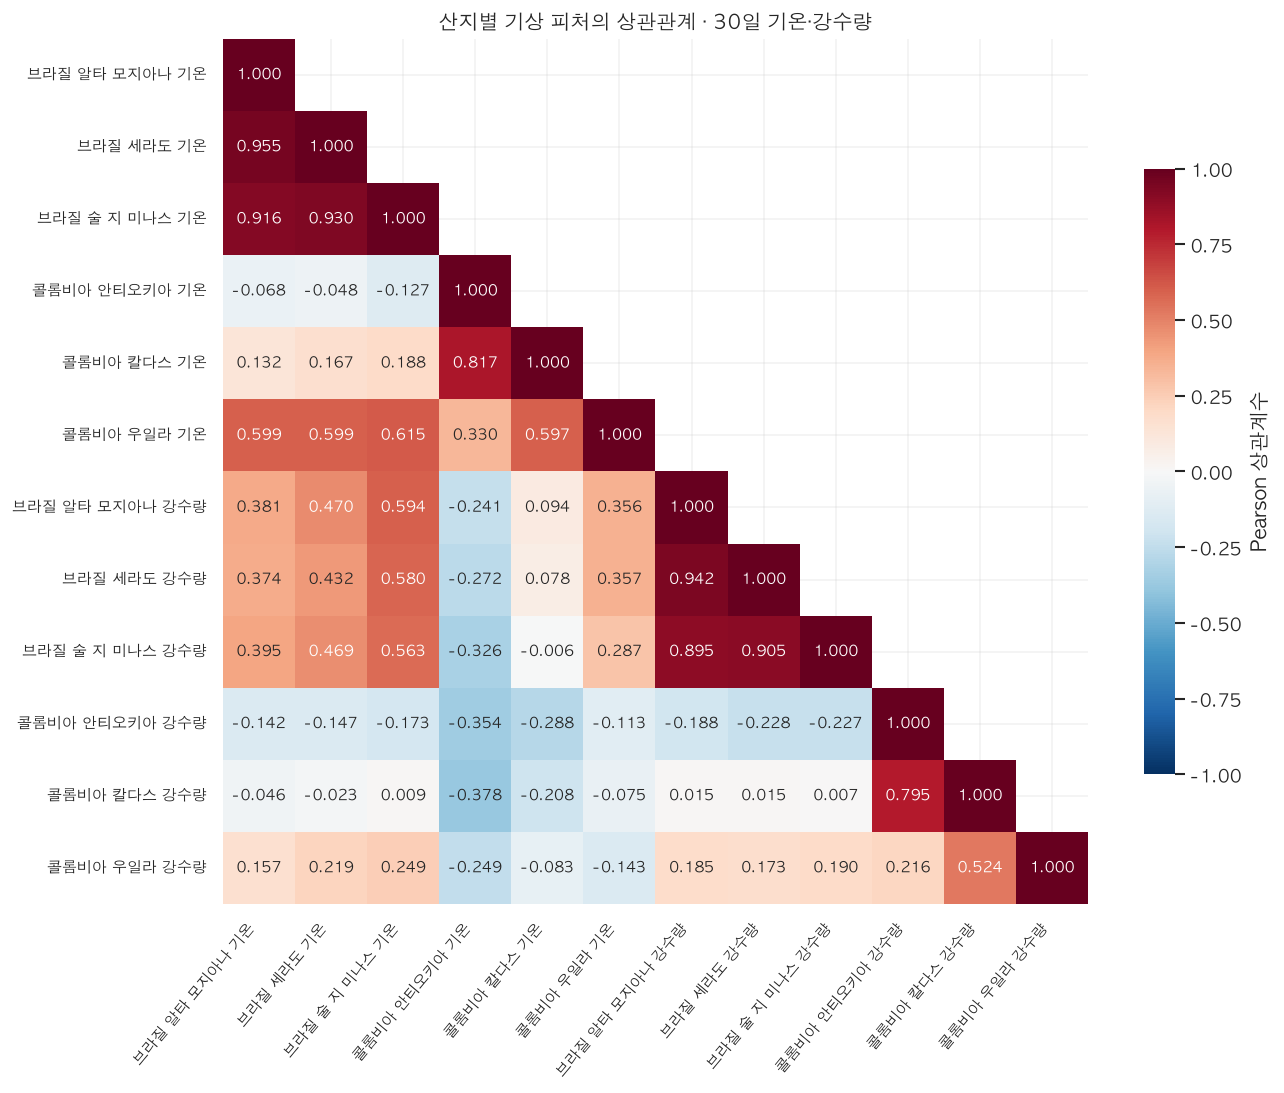

기상 피처 1,기상 피처 2,Pearson 상관계수,Spearman 상관계수
브라질 알타 모지아나 기온,브라질 세라도 기온,0.955,0.950
브라질 알타 모지아나 강수량,브라질 세라도 강수량,0.942,0.967
브라질 세라도 기온,브라질 술 지 미나스 기온,0.930,0.902
브라질 알타 모지아나 기온,브라질 술 지 미나스 기온,0.916,0.889
브라질 세라도 강수량,브라질 술 지 미나스 강수량,0.905,0.932
브라질 알타 모지아나 강수량,브라질 술 지 미나스 강수량,0.895,0.942
콜롬비아 안티오키아 기온,콜롬비아 칼다스 기온,0.817,0.763


,VIF,점검
기상 피처,,
브라질 세라도 기온,18.50,5 이상 · 함께 확인
브라질 알타 모지아나 기온,17.57,5 이상 · 함께 확인
브라질 술 지 미나스 기온,16.96,5 이상 · 함께 확인
브라질 세라도 강수량,13.31,5 이상 · 함께 확인
브라질 알타 모지아나 강수량,12.29,5 이상 · 함께 확인
브라질 술 지 미나스 강수량,7.43,5 이상 · 함께 확인
콜롬비아 안티오키아 기온,7.36,5 이상 · 함께 확인
콜롬비아 칼다스 기온,7.14,5 이상 · 함께 확인
콜롬비아 칼다스 강수량,4.80,5 미만


술 지 미나스–세라도 기온 상관: 0.930 | |r|≥0.8인 기상 조합: 7개


In [ ]:
weather_order = [f"{region}_{kind}" for kind in ["temp_30d", "rain_30d"] for region in region_labels]
weather_corr = dev[weather_order].corr(method="pearson")
weather_rank_corr = dev[weather_order].corr(method="spearman")
fig, ax = plt.subplots(figsize=(11, 9), layout="constrained")
sns.heatmap(
    weather_corr.rename(index=short_labels, columns=short_labels),
    mask=np.triu(np.ones_like(weather_corr, dtype=bool), k=1),
    annot=True,
    fmt=".3f",
    annot_kws={"fontsize": 9},
    vmin=-1,
    vmax=1,
    center=0,
    cmap="RdBu_r",
    square=True,
    ax=ax,
    cbar_kws={"label": "Pearson 상관계수", "shrink": 0.7},
)
ax.set(title="산지별 기상 피처의 상관관계 · 30일 기온·강수량", xlabel="", ylabel="")
ax.tick_params(axis="x", labelrotation=50, labelsize=9)
ax.tick_params(axis="y", labelrotation=0, labelsize=9)
plt.setp(ax.get_xticklabels(), ha="right")
plt.show()

# 자기 자신과 중복 조합을 뺀다. 0.8은 자동 삭제 기준이 아니라 살펴볼 조합을 고르는 기준이다.
upper = weather_corr.where(np.triu(np.ones_like(weather_corr, dtype=bool), k=1))
weather_pairs = upper.stack().dropna().rename("pearson").rename_axis(["feature_a", "feature_b"]).reset_index()
high_weather_pairs = weather_pairs.loc[weather_pairs["pearson"].abs() >= 0.8].copy()
high_weather_pairs["spearman"] = [
    weather_rank_corr.loc[a, b] for a, b in zip(high_weather_pairs["feature_a"], high_weather_pairs["feature_b"])
]
high_weather_pairs = high_weather_pairs.sort_values("pearson", key=lambda column: column.abs(), ascending=False)
display(
    high_weather_pairs.assign(
        feature_a=lambda table: table["feature_a"].map(short_labels),
        feature_b=lambda table: table["feature_b"].map(short_labels),
    )
    .rename(
        columns={
            "feature_a": "기상 피처 1",
            "feature_b": "기상 피처 2",
            "pearson": "Pearson 상관계수",
            "spearman": "Spearman 상관계수",
        }
    )
    .style.hide(axis="index")
    .format({"Pearson 상관계수": "{:.3f}", "Spearman 상관계수": "{:.3f}"})
)

weather_design = sm.add_constant(dev[weather_order])
weather_vif = pd.Series(
    {
        name: variance_inflation_factor(weather_design.to_numpy(), i)
        for i, name in enumerate(weather_design.columns)
        if name != "const"
    },
    name="VIF",
)
weather_vif = weather_vif.sort_values(ascending=False)
display(
    weather_vif.rename(index=short_labels)
    .rename_axis("기상 피처")
    .to_frame()
    .assign(점검=lambda table: np.where(table["VIF"] >= 5, "5 이상 · 함께 확인", "5 미만"))
    .style.format({"VIF": "{:.2f}"})
)
sul_cerrado_corr = weather_corr.loc["br_sul_minas_temp_30d", "br_cerrado_temp_30d"]
print(f"술 지 미나스–세라도 기온 상관: {sul_cerrado_corr:.3f} | |r|≥0.8인 기상 조합: {len(high_weather_pairs)}개")


알타 모지아나–세라도 기온 간 상관계수가 0.955, 미나스–세라도 기온 상관계수는 0.930이었다. 브라질 세 산지의 강수량 상관계수가 0.895~0.942로 매우 강한 상관관계를 보였다. Pearson 기준 0.8 이상인 조합은 총 7개였다.

VIF > 5 이상인 기상 변수들이 많아서 변수간 다중공선성에 주의해야할 것 같다.

### 회귀선으로 확인하기

각 피처 하나를 x, 종가를 y로 놓았다. 선은 개발 구간 전체에 맞춘 단순 회귀선이다. 패널의 R²도 같은 구간에서의 설명력이라 예측 성능과는 다르다. 날짜가 이어진 데이터여서 일반적인 독립 표본 부트스트랩 신뢰구간은 표시하지 않았다. 아래에는 미래 수익률과의 Spearman 상관이 큰 6개도 따로 그린다.

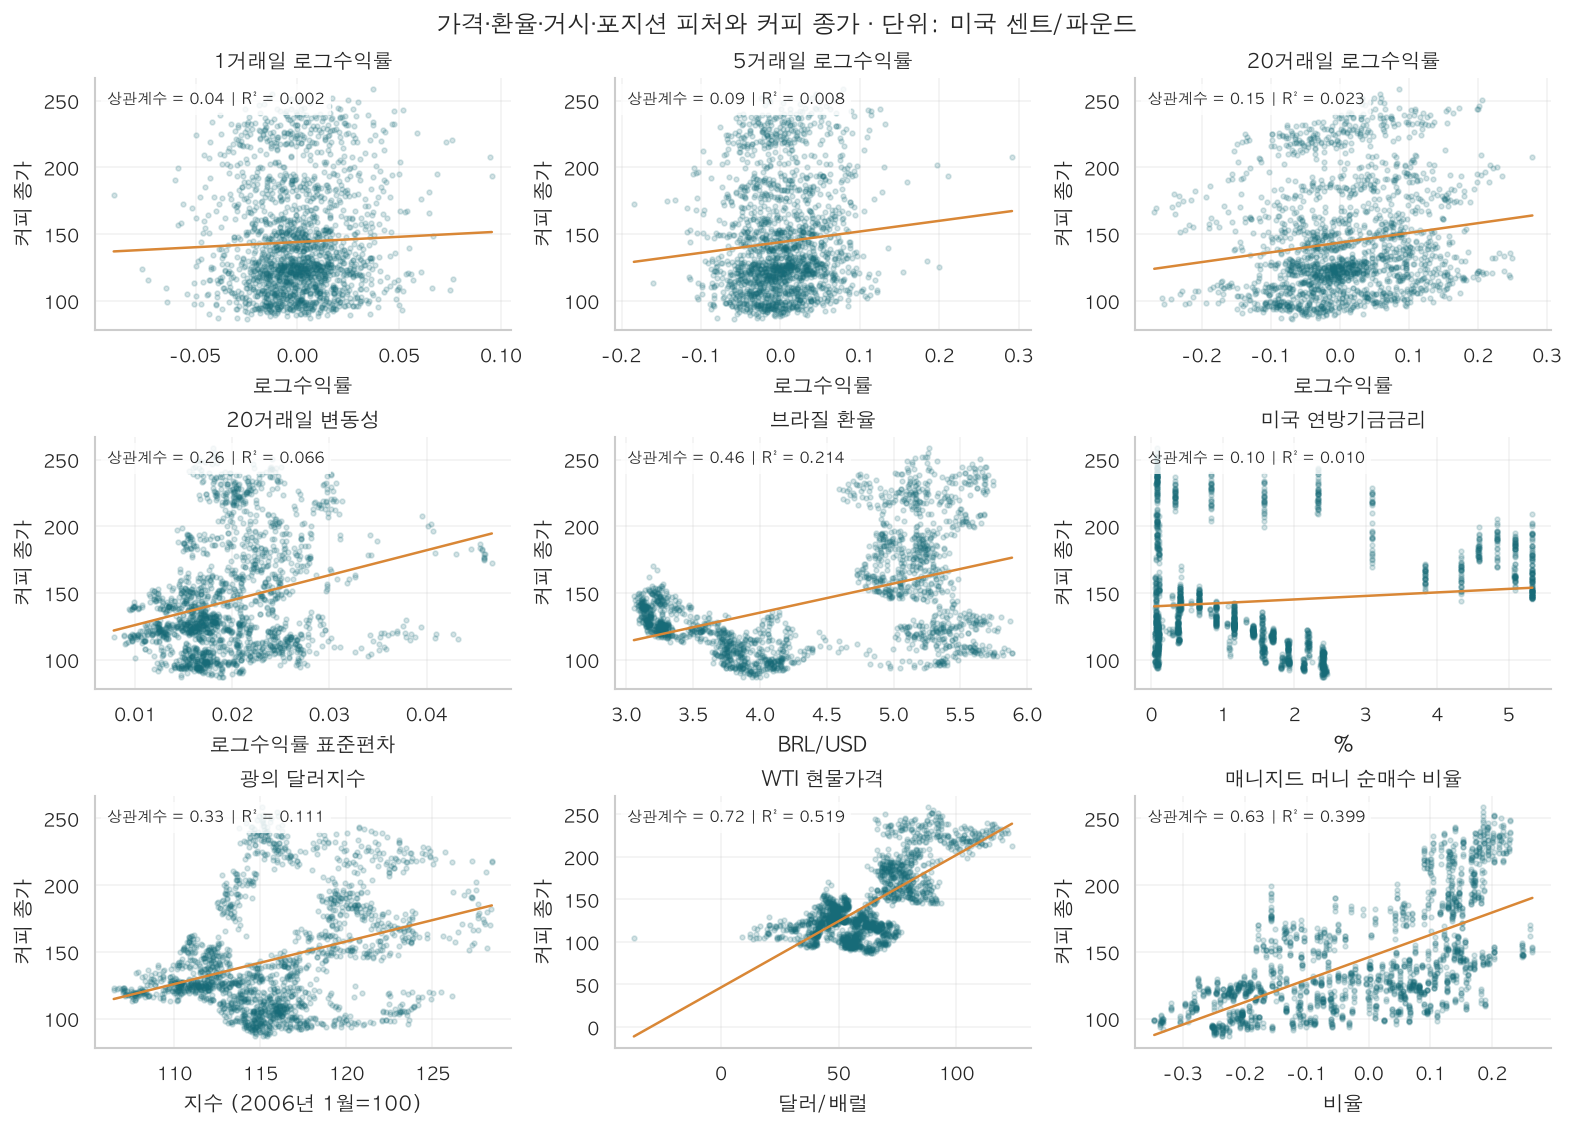

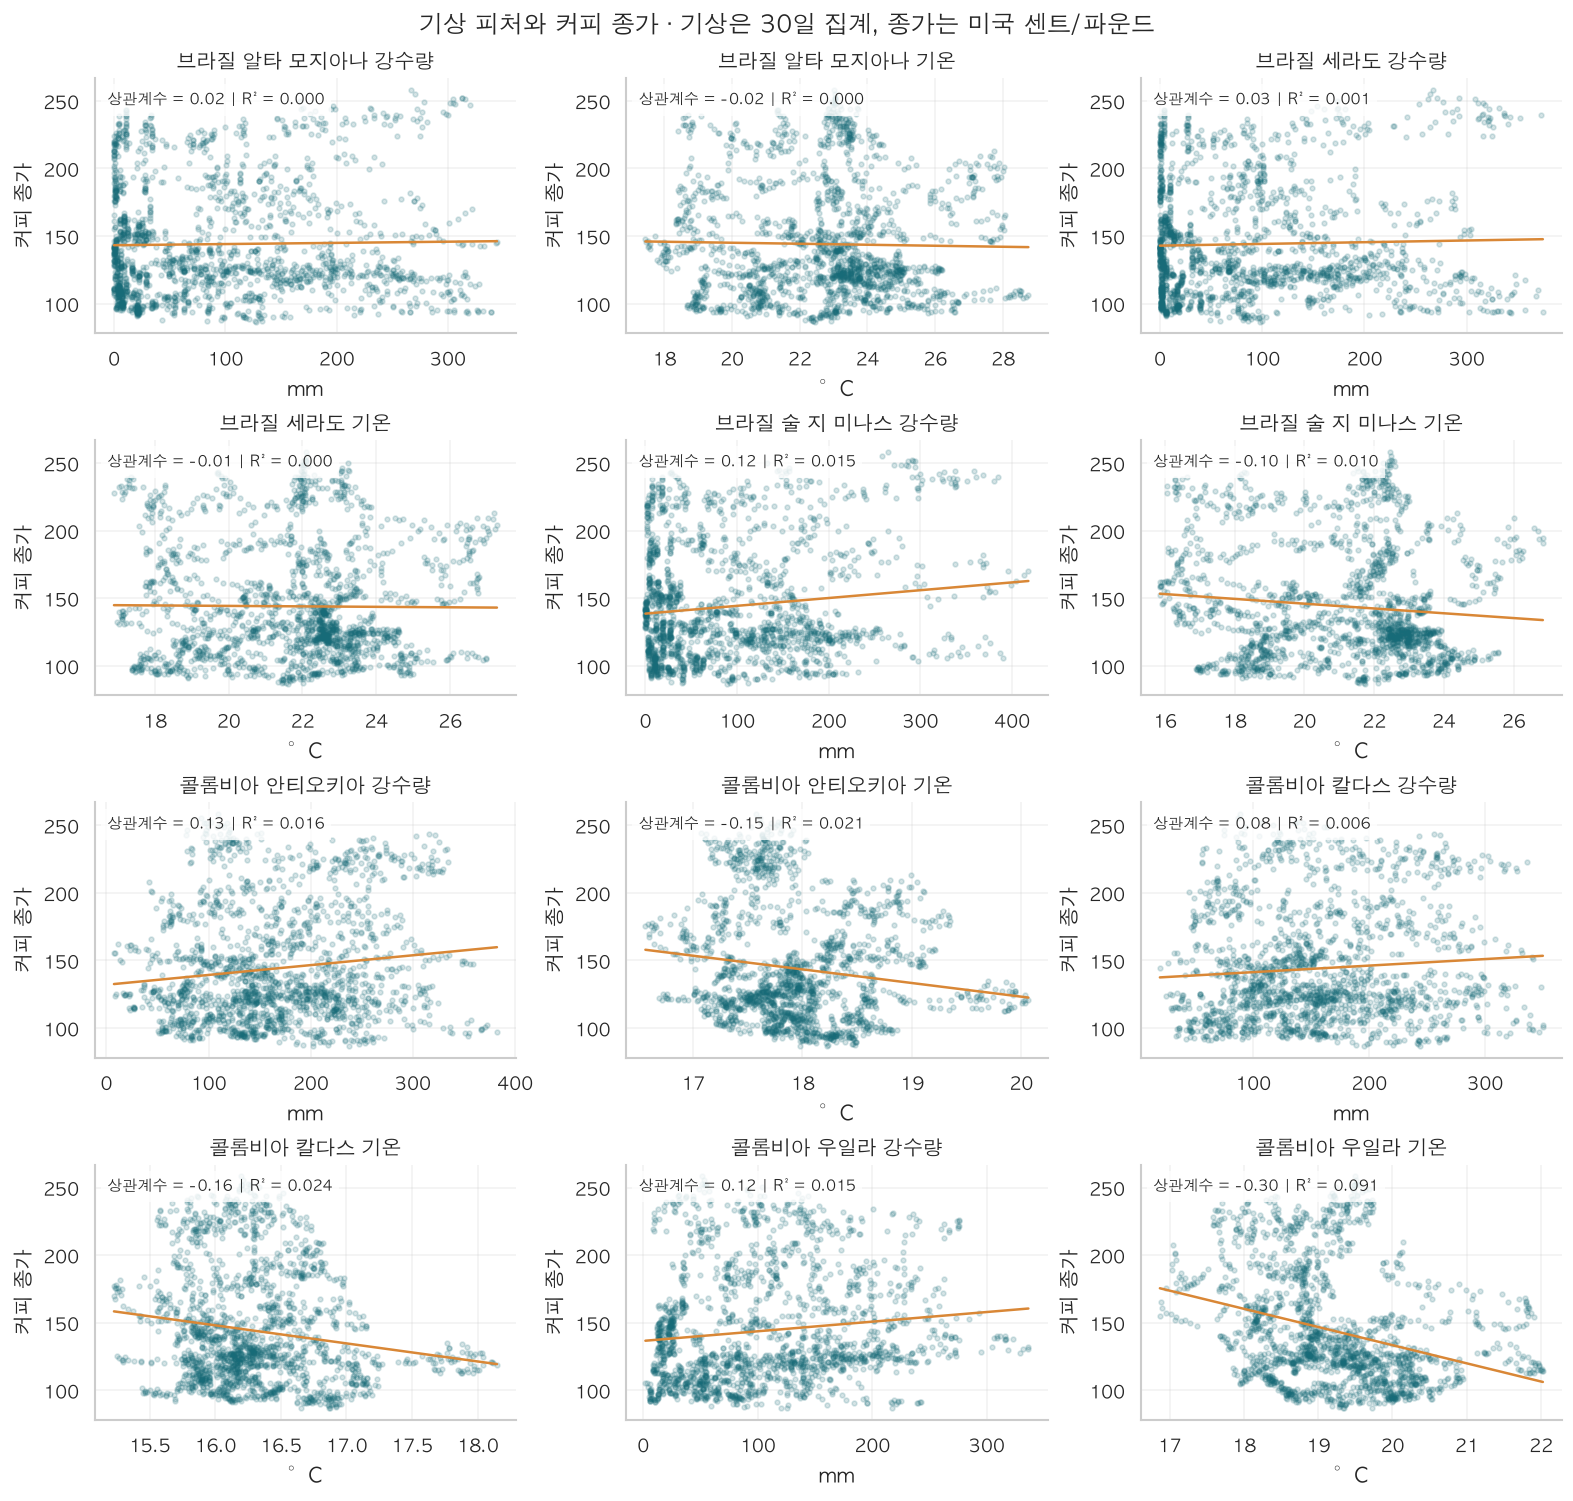

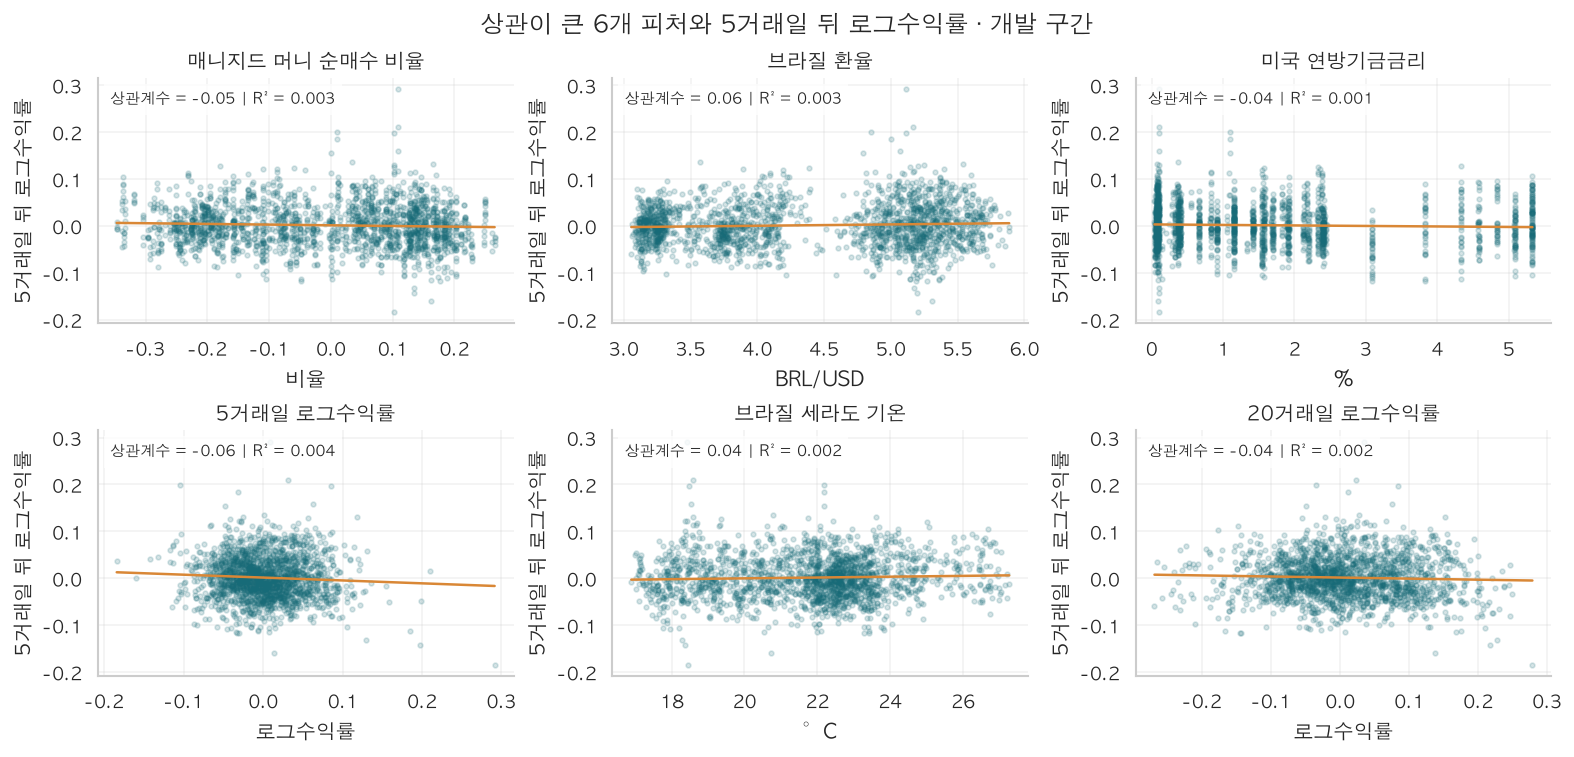

In [ ]:
def plot_relationships(columns, target, title):
    rows = (len(columns) + 2) // 3
    fig, axes = plt.subplots(rows, 3, figsize=(13, rows * 3.1), layout="constrained")
    for ax, name in zip(axes.flat, columns):
        sns.regplot(
            data=dev,
            x=name,
            y=target,
            ci=None,
            ax=ax,
            scatter_kws={"s": 8, "alpha": 0.18, "color": "#176B78"},
            line_kws={"color": "#D98736", "linewidth": 1.5},
        )
        r = pearson.loc[name, target]
        ax.set(title=short_labels[name], xlabel=units[name], ylabel=short_labels[target])
        ax.text(
            0.03,
            0.95,
            f"상관계수 = {r:.2f} | R² = {r**2:.3f}",
            transform=ax.transAxes,
            va="top",
            fontsize=9,
            bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "none"},
        )
    for ax in axes.flat[len(columns) :]:
        ax.set_visible(False)
    fig.suptitle(title)
    plt.show()


non_weather = [name for name in FEATURES if name not in weather_features]
plot_relationships(non_weather, "close", "가격·환율·거시·포지션 피처와 커피 종가 · 단위: 미국 센트/파운드")
plot_relationships(weather_features, "close", "기상 피처와 커피 종가 · 기상은 30일 집계, 종가는 미국 센트/파운드")
plot_relationships(list(order[:6]), TARGET, "상관이 큰 6개 피처와 5거래일 뒤 로그수익률 · 개발 구간")


### 단순 회귀의 적합도와 검정

R²는 회귀선이 같은 구간의 변동을 얼마나 설명하는지 나타낸다. 검정은 별도로, `미래 수익률 ~ 피처 하나`에서 **기울기가 0인가**를 확인한다. 5일 수익률은 이웃한 정답끼리 겹치므로 [HAC 표준오차](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.RegressionResults.get_robustcov_results.html)를 쓰고, 여러 피처를 한꺼번에 살펴본 만큼 [FDR 보정](https://www.statsmodels.org/stable/generated/statsmodels.stats.multitest.multipletests.html)도 같이 표시한다. HAC 지연은 20개 관측치로 고정했다.

유의한 p값이 나와도 추세나 계절성 문제가 모두 해결되는 것은 아니다. 예측에 도움이 되는지는 **2016~2021년에 맞춘 단순 회귀를 2022~2023년에 적용한 R²**도 같이 본다. 검증 R²가 음수면 그 구간의 실제 평균을 기준으로 한 설명력도 못 얻은 것이다. 종가 수준의 회귀에는 추세가 섞이기 쉬워 p값을 붙이지 않았다.

In [ ]:
regression_rows = []
for name in FEATURES:
    x_dev = sm.add_constant(dev[[name]], has_constant="add")
    price_fit = sm.OLS(dev["close"], x_dev).fit()
    return_fit = sm.OLS(dev[TARGET], x_dev).fit(cov_type="HAC", cov_kwds={"maxlags": 20})
    train_fit = sm.OLS(train[TARGET], sm.add_constant(train[[name]], has_constant="add")).fit()
    val_pred = train_fit.predict(sm.add_constant(val[[name]], has_constant="add"))
    regression_rows.append(
        {
            "feature": name,
            "price_r2": price_fit.rsquared,
            "return_r2": return_fit.rsquared,
            "val_r2": r2_score(val[TARGET], val_pred),
            "hac_p": return_fit.pvalues[name],
        }
    )
regression = pd.DataFrame(regression_rows).set_index("feature")
regression["fdr_p"] = multipletests(regression["hac_p"], method="fdr_bh")[1]
regression = regression.loc[order]
display(
    regression.rename(
        index=short_labels,
        columns={
            "price_r2": "종가 R²",
            "return_r2": "수익률 R²",
            "val_r2": "검증 수익률 R²",
            "hac_p": "기울기 p값 (HAC)",
            "fdr_p": "보정 p값 (FDR)",
        },
    )
    .rename_axis("피처")
    .style.format("{:.4f}")
)
print(f"FDR 보정 p값 < 0.05: {int((regression['fdr_p'] < 0.05).sum())} / {len(FEATURES)}개")


,종가 R²,수익률 R²,검증 수익률 R²,기울기 p값 (HAC),보정 p값 (FDR)
피처,,,,,
매니지드 머니 순매수 비율,0.3992,0.0026,-0.0047,0.2532,0.7986
브라질 환율,0.2142,0.0031,-0.0331,0.1604,0.7986
미국 연방기금금리,0.0105,0.0015,-0.0574,0.4189,0.7986
5거래일 로그수익률,0.0077,0.0038,-0.0070,0.1423,0.7986
브라질 세라도 기온,0.0001,0.0018,-0.0044,0.3649,0.7986
20거래일 로그수익률,0.0226,0.0018,-0.0111,0.3542,0.7986
브라질 알타 모지아나 기온,0.0004,0.0015,-0.0074,0.4025,0.7986
브라질 술 지 미나스 기온,0.0104,0.0009,-0.0254,0.5324,0.7986
광의 달러지수,0.1107,0.0020,-0.0032,0.3748,0.7986


FDR 보정 p값 < 0.05: 0 / 21개


### 여기까지 보고 든 생각

브라질 세 곳은 건기와 우기가 확실히 갈렸다. 월평균 누적 강수량이 7월에는 약 1~4mm, 1월에는 208~236mm였다. 초반 빈칸을 전체 중앙값으로 채우는 건 맞지 않는 선택이었다.

종가와의 Pearson 상관은 WTI 0.721, COT 순매수 비율 0.632로 컸다. 그런데 5일 뒤 수익률로 바꾸면 각각 -0.006, -0.051로 약해졌다. 21개 피처 모두 수익률과의 상관계수 절댓값이 0.062보다 작았고, 단순 회귀의 검증 R²도 전부 음수였다. HAC·FDR 적용 후 5% 기준을 통과한 피처는 없었다.

이 데이터로 5일 뒤 방향을 잡는 게 생각보다 어렵다. 기상이 쓸모없다는 결론까지 갈 수는 없고, 계절별 편차나 더 긴 시차를 다음 실험 후보로 남겨두려 한다.

## 4. 기준 모델 세 개

Ridge는 alpha 네 개만 비교한다. CatBoost는 깊이 4로 작게 시작하고, 검증 RMSE가 더 좋아지지 않으면 멈춘다. 테스트 결과를 보고 설정을 다시 고르지는 않는다.

방향성 정확도는 `sign(실제 수익률) == sign(예측 수익률)`의 비율이다. **0은 보합**으로 센다. 그래서 항상 0을 내는 Naive는 실제 수익률도 0일 때만 방향을 맞힌다. 이 모델의 주 비교 기준은 MAE·RMSE다.

In [16]:
ridge_trials = []
for alpha in (0.1, 1.0, 10.0, 100.0):
    candidate = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
    candidate.fit(train[FEATURES], train[TARGET])
    ridge_trials.append(
        {"alpha": alpha, "val_rmse": root_mean_squared_error(val[TARGET], candidate.predict(val[FEATURES]))}
    )
ridge_trials = pd.DataFrame(ridge_trials).sort_values("val_rmse")
best_alpha = float(ridge_trials.iloc[0]["alpha"])

cat_params = dict(
    depth=4,
    learning_rate=0.03,
    l2_leaf_reg=5,
    loss_function="RMSE",
    random_seed=SEED,
    thread_count=4,
    allow_writing_files=False,
    verbose=False,
)
cat_search = CatBoostRegressor(iterations=1000, **cat_params)
cat_search.fit(
    train[FEATURES],
    train[TARGET],
    eval_set=(val[FEATURES], val[TARGET]),
    early_stopping_rounds=100,
    use_best_model=True,
)
best_iterations = int(cat_search.best_iteration_) + 1
val_scores = pd.DataFrame(
    [
        {"model": "가격 유지 (수익률 0)", "val_rmse": root_mean_squared_error(val[TARGET], np.zeros(len(val)))},
        {"model": f"Ridge 회귀 (규제 강도={best_alpha:g})", "val_rmse": ridge_trials.iloc[0]["val_rmse"]},
        {
            "model": f"CatBoost (트리 {best_iterations}개)",
            "val_rmse": root_mean_squared_error(val[TARGET], cat_search.predict(val[FEATURES])),
        },
    ]
).set_index("model")
display(val_scores.round(6).rename_axis("모델").rename(columns={"val_rmse": "검증 오차 (RMSE)"}))

,검증 오차 (RMSE)
모델,
가격 유지 (수익률 0),0.047069
Ridge 회귀 (규제 강도=100),0.050050
CatBoost (트리 31개),0.047154


In [17]:
ridge = make_pipeline(StandardScaler(), Ridge(alpha=best_alpha))
ridge.fit(dev[FEATURES], dev[TARGET])
catboost = CatBoostRegressor(iterations=best_iterations, **cat_params)
catboost.fit(dev[FEATURES], dev[TARGET])

predictions = pd.DataFrame(
    {
        "Naive Persistence": np.zeros(len(test)),
        "Ridge Regression": ridge.predict(test[FEATURES]),
        "CatBoost": catboost.predict(test[FEATURES]),
    },
    index=test.index,
)
assert np.isfinite(predictions.to_numpy()).all()
metrics = pd.DataFrame(
    [
        {
            "model": name,
            "MAE": mean_absolute_error(test[TARGET], pred),
            "RMSE": root_mean_squared_error(test[TARGET], pred),
            "Directional Accuracy (%)": np.mean(np.sign(test[TARGET]) == np.sign(pred)) * 100,
        }
        for name, pred in predictions.items()
    ]
).set_index("model")
display(
    metrics.rename(index=model_labels, columns=metric_labels)
    .rename_axis("모델")
    .style.format(
        {
            metric_labels["MAE"]: "{:.6f}",
            metric_labels["RMSE"]: "{:.6f}",
            metric_labels["Directional Accuracy (%)"]: "{:.2f}",
        }
    )
)
print(f"테스트 예측 {len(test):,}건 | Ridge 규제 강도={best_alpha:g} | CatBoost 트리 {best_iterations}개")

,평균절대오차 (MAE),제곱평균제곱근오차 (RMSE),방향성 정확도 (%)
모델,,,
가격 유지 (Naive),0.042810,0.054442,0.40
Ridge 회귀,0.044329,0.057099,46.79
CatBoost,0.043006,0.054674,47.19


테스트 예측 498건 | Ridge 규제 강도=100 | CatBoost 트리 31개


## 5. 모델이 주로 본 피처

CatBoost의 내장 중요도(PredictionValuesChange)를 본다. 전체 피처의 합이 100이 되며, 이 중 상위 10개만 그린다. 학습한 모델이 많이 사용한 피처라는 뜻이지, 그 변수가 가격을 움직였다는 뜻은 아니다.

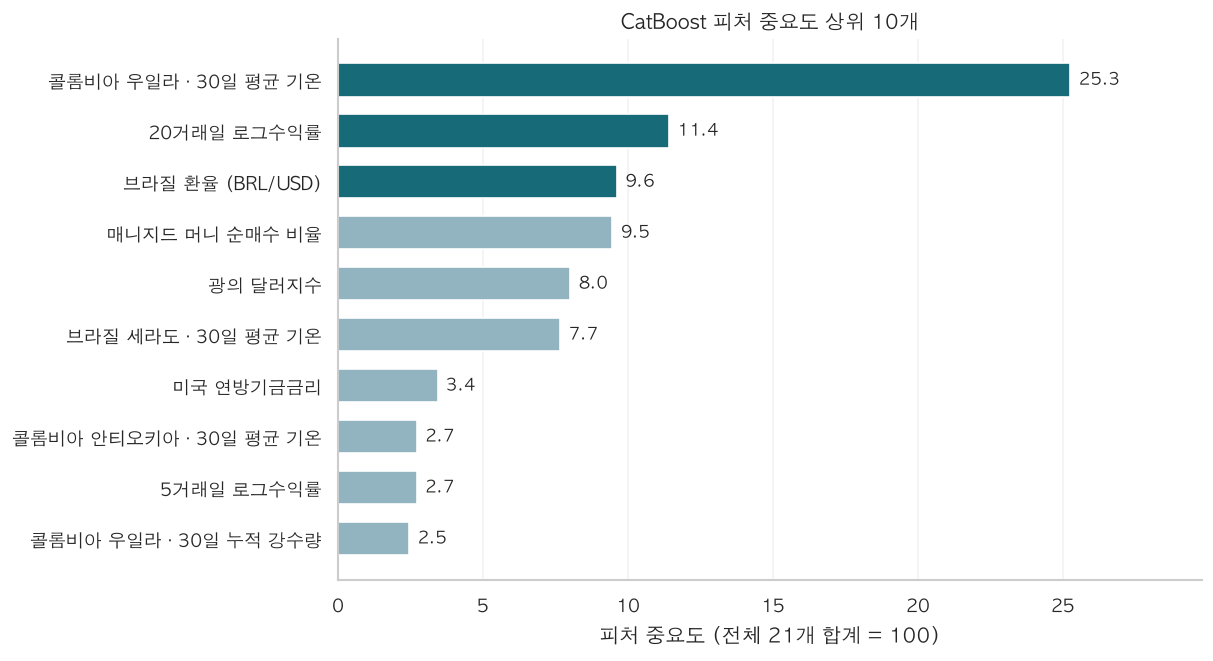

In [18]:
importance = pd.Series(catboost.feature_importances_, index=FEATURES, name="importance").sort_values(ascending=False)
top10 = importance.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 5.4), layout="constrained")
bars = ax.barh(top10.index.map(feature_labels), top10.values, color=["#91B4C0"] * 7 + ["#176B78"] * 3, height=0.65)
ax.bar_label(bars, fmt="%.1f", padding=5, fontsize=10)
ax.set(title="CatBoost 피처 중요도 상위 10개", xlabel="피처 중요도 (전체 21개 합계 = 100)", ylabel="")
ax.set_xlim(0, top10.max() * 1.18)
ax.grid(axis="y", visible=False)
plt.show()

## 6. 예측 수익률을 가격으로 돌려 보기

예측 가격은 `Close[T] × exp(예측 수익률)`이고, **T가 아니라 T+5 거래일 날짜**에 그린다. 매일 새로 계산한 5일 앞 예측을 이어 그린 것이므로 2년치를 한 번에 예측한 곡선은 아니다. 현재 가격을 출발점으로 쓰기 때문에 선이 비슷하게 보여도, 성능은 위의 수익률 오차와 Naive 비교로 판단한다.

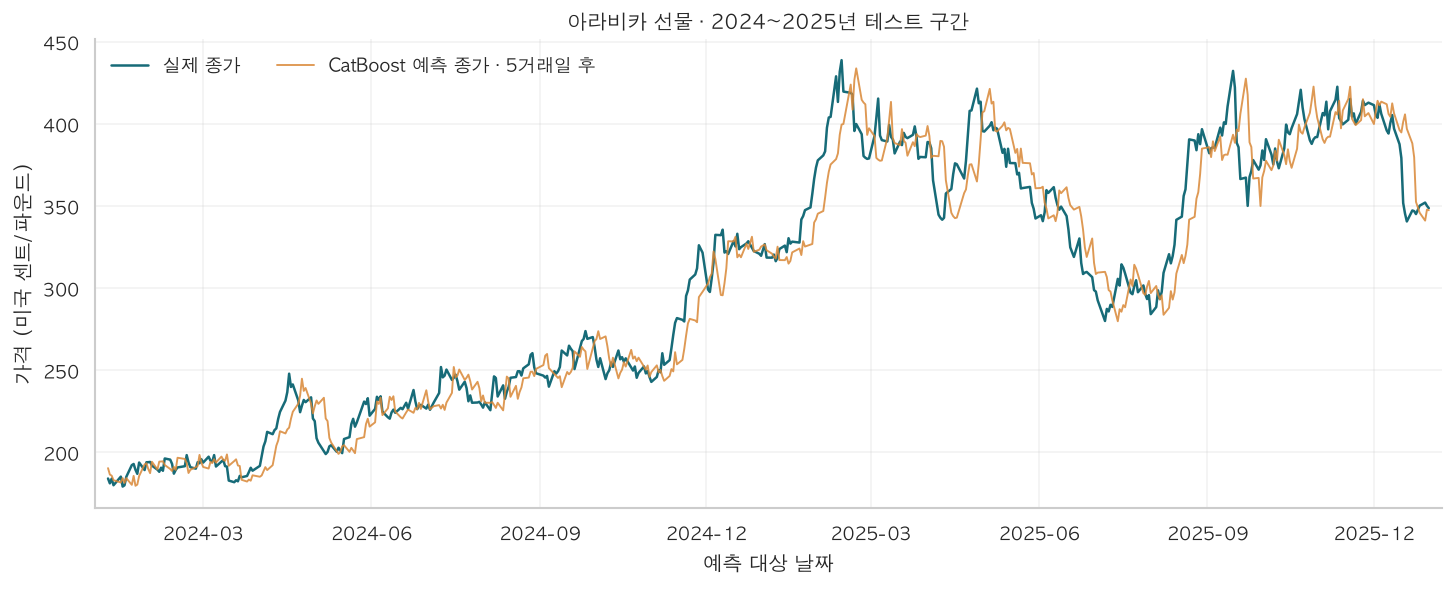

In [19]:
price_comparison = pd.DataFrame(
    {
        "target_date": test["target_date"],
        "Actual close": test["future_close"],
        "CatBoost forecast": test["close"] * np.exp(predictions["CatBoost"]),
    }
).set_index("target_date")
fig, ax = plt.subplots(figsize=(12, 4.8), layout="constrained")
ax.plot(price_comparison.index, price_comparison["Actual close"], label="실제 종가", color="#176B78", linewidth=1.5)
ax.plot(
    price_comparison.index,
    price_comparison["CatBoost forecast"],
    label="CatBoost 예측 종가 · 5거래일 후",
    color="#D98736",
    linewidth=1.15,
    alpha=0.85,
)
ax.set(title="아라비카 선물 · 2024~2025년 테스트 구간", xlabel="예측 대상 날짜", ylabel="가격 (미국 센트/파운드)")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.legend(frameon=False, loc="upper left", ncols=2)
ax.margins(x=0.01)
plt.show()

In [20]:
best_model = metrics["RMSE"].idxmin()
top_features = ", ".join(f"{feature_labels[name]} ({value:.1f})" for name, value in importance.head(3).items())
rmse_change = (metrics.loc["CatBoost", "RMSE"] / metrics.loc["Naive Persistence", "RMSE"] - 1) * 100
print(
    f"최저 RMSE 모델: {model_labels[best_model]} | CatBoost의 Naive 대비 RMSE 변화: {rmse_change:+.1f}%\n중요도 상위 피처: {top_features}"
)

최저 RMSE 모델: 가격 유지 (Naive) | CatBoost의 Naive 대비 RMSE 변화: +0.4%
중요도 상위 피처: 콜롬비아 우일라 · 30일 평균 기온 (25.3), 20거래일 로그수익률 (11.4), 브라질 환율 (BRL/USD) (9.6)


기상 버퍼를 추가해 초반 피처를 실제 관측값으로 계산했다. CatBoost는 깊이 4·트리 31개로 학습됐고, 테스트 RMSE는 Naive보다 약 0.4% 컸다.

우일라의 30일 평균 기온이 중요도 25.3으로 가장 높았다. 미래 수익률과의 단순 상관은 거의 없는데 트리 모델에서는 많이 쓰인 셈이다. 비선형 관계인지, 특정 시기의 구분에 쓰인 것인지는 이번 결과만으로 알 수 없다. 다음에는 가격 피처만 쓴 경우와 외부 피처를 더한 경우를 같은 구간에서 비교해보고 싶다.